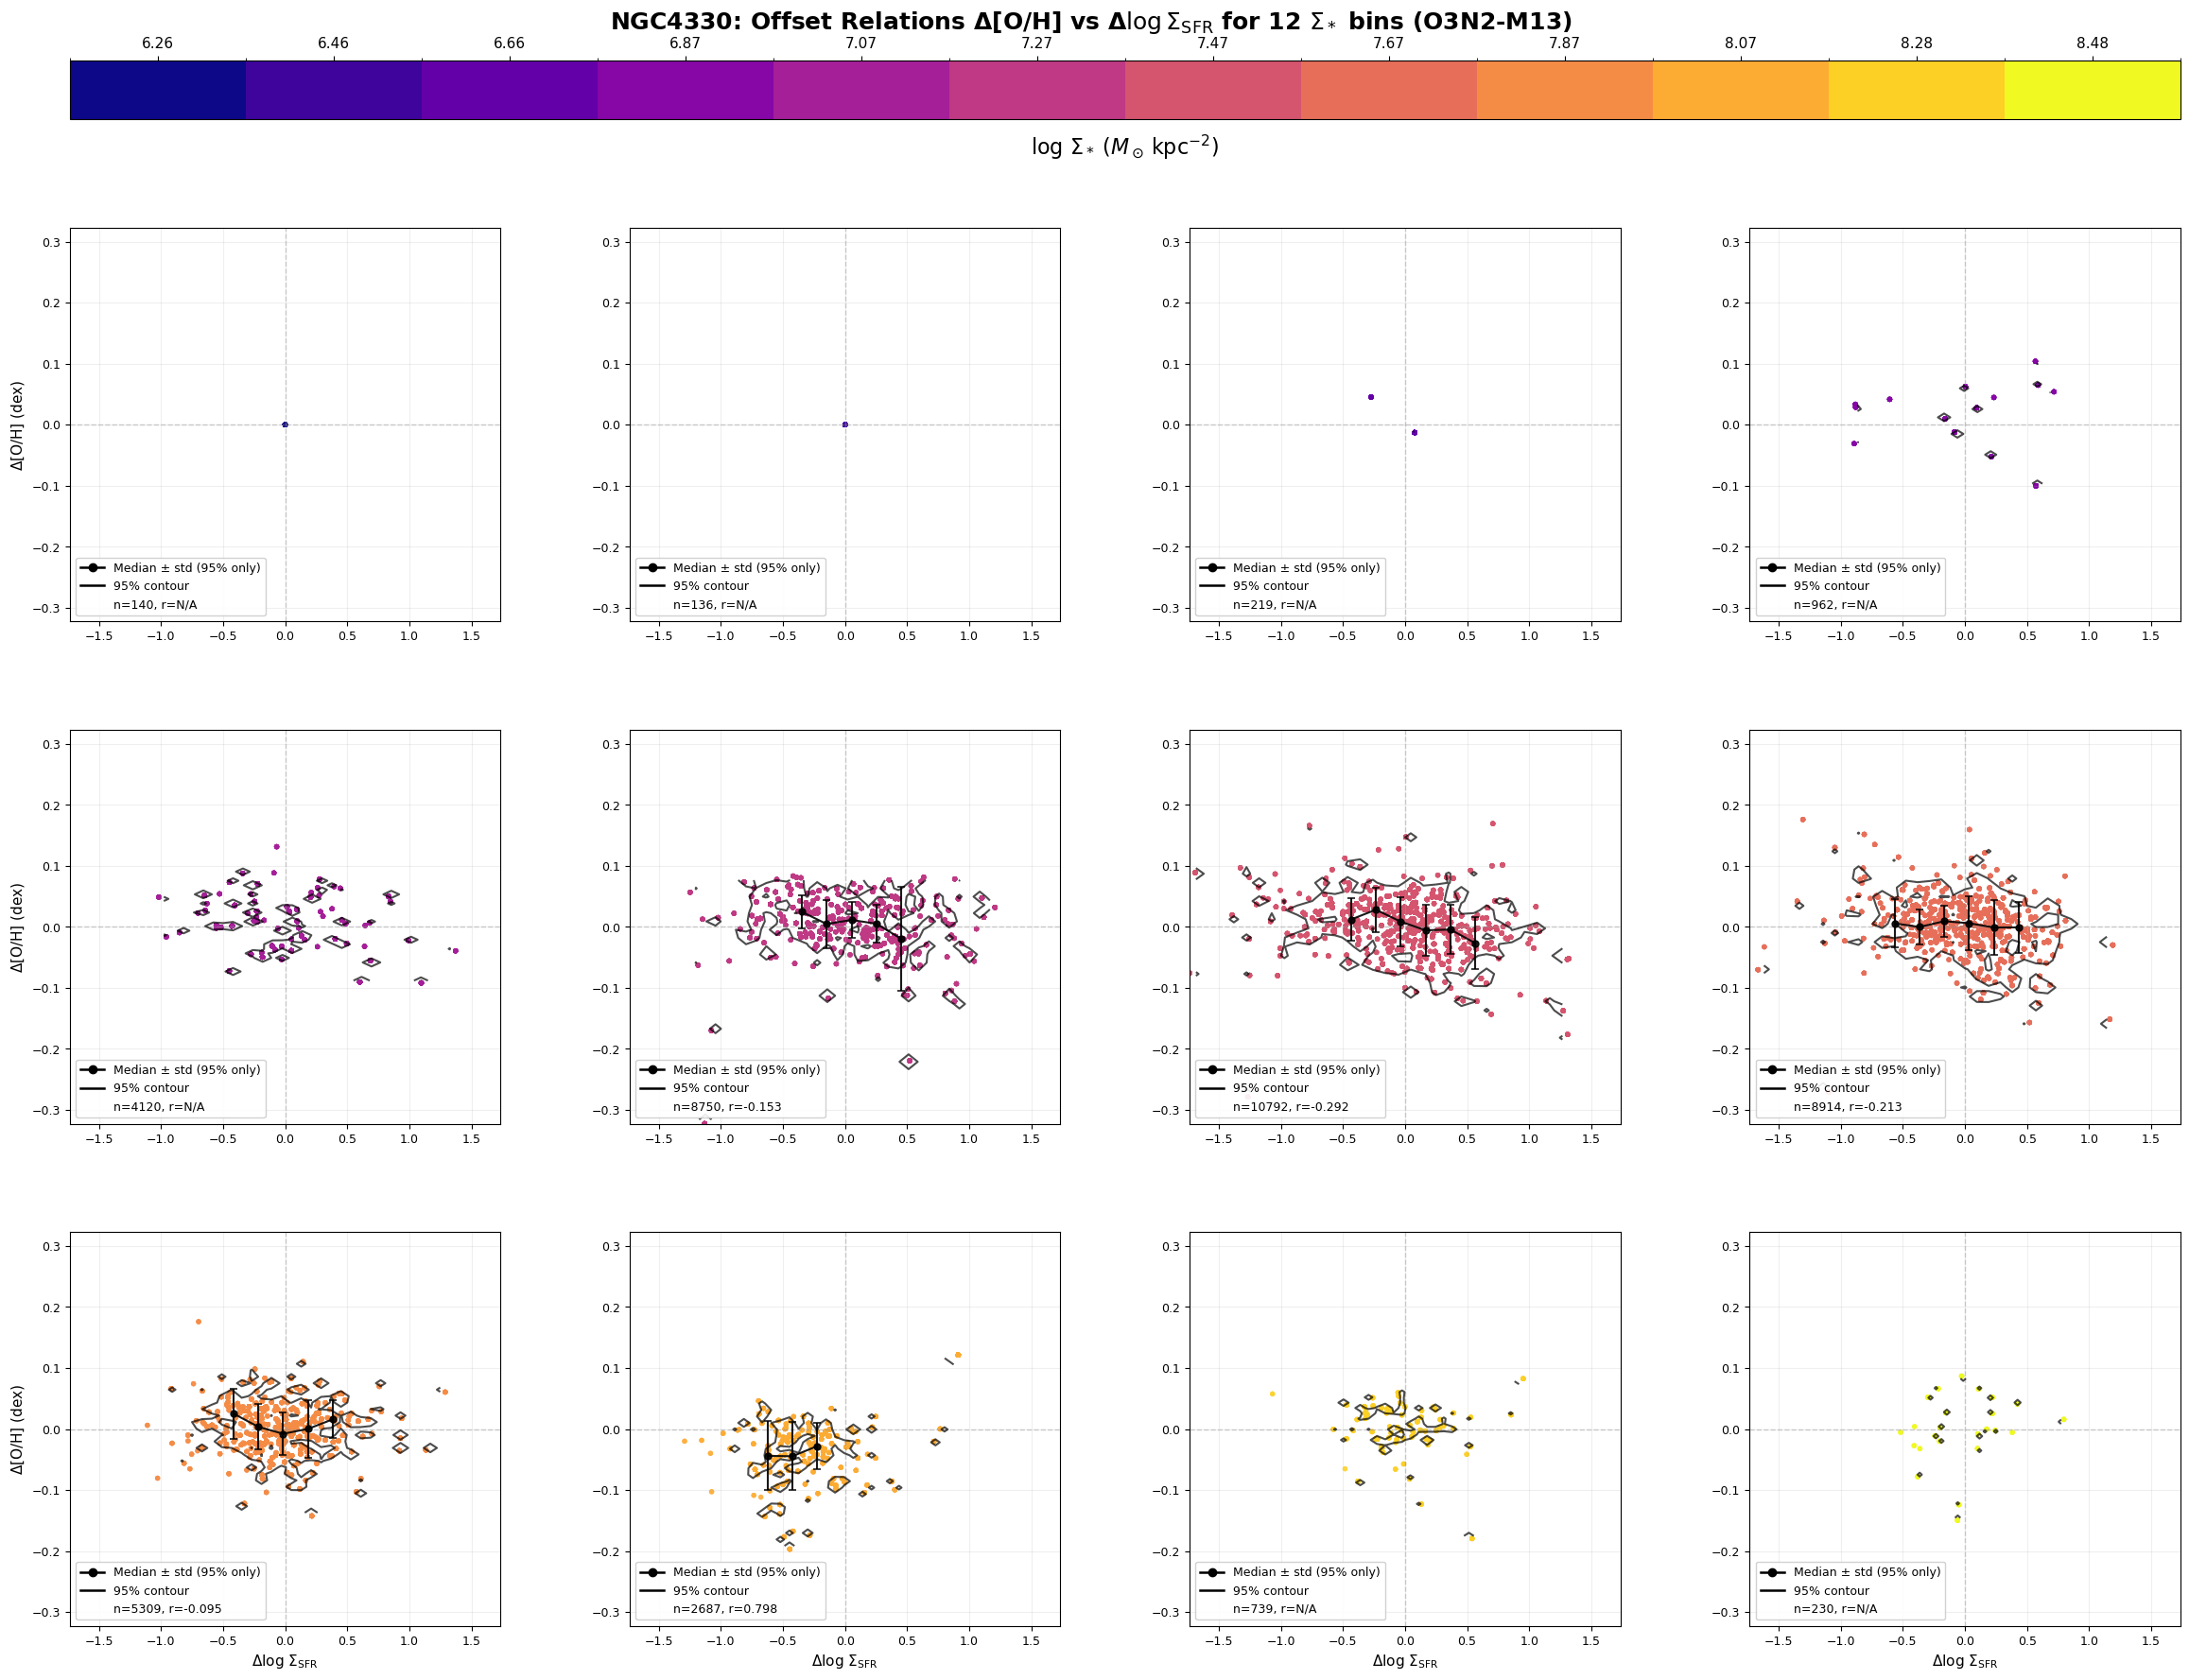


NGC4330: 12-panel offset relation grid complete!
  Number of Σ* bins: 12
  Σ* range: 6.160 to 8.578
  Global Δlog(Σ_SFR) axis limits: ±1.734
  Global Δ[O/H] axis limits: ±0.323


In [6]:
# ------------------------------------------------------------------
# Plot 12 separate offset relations (one per Σ* bin) in 3x4 grid
# With shared colorbar at the top
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins.

    Only keep bins where there are at least `min_unique` unique y-data
    points within the bin. Returns bin centers, medians, stds, and counts.
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        # Require sufficient unique y values in this bin
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 1.  Define 12 Σ* bins
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # ------------------------------------------------------------------
    # 2.  Calculate global axis limits (same for all subplots)
    # ------------------------------------------------------------------
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)
            
            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
    
    # ------------------------------------------------------------------
    # 3.  Create 3x4 subplot grid with colorbar at top
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    
    # Create grid: 1 row for colorbar, 3 rows for subplots
    gs = gridspec.GridSpec(4, 4, figure=fig, 
                          height_ratios=[0.15, 1, 1, 1],
                          hspace=0.35, wspace=0.3,
                          top=0.96, bottom=0.04, left=0.05, right=0.98)
    
    # Create colorbar axis at the top (spanning all columns)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Create 12 subplots in 3x4 grid
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)
    
    # ------------------------------------------------------------------
    # 4.  Plot each Σ* bin in its own subplot
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]
        
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        n_pixels = np.sum(bin_mask)
        
        if n_pixels > 0:
            # Get values in this bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            # Calculate offsets WITHIN this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)
            
            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean
            
            # Validity mask in this bin
            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            
            # Get color for this bin
            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
            
            # Scatter plot (all valid points in bin)
            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr], 
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)
            
            # ------------------------------------------------------------------
            # Calculate 95% contour and mask
            # ------------------------------------------------------------------
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True
            
            # ------------------------------------------------------------------
            # Calculate median trend using only points inside 95% contour
            # and requiring at least `min_unique` unique y-values per bin
            # ------------------------------------------------------------------
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size > 0
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)
            
            # ------------------------------------------------------------------
            # Pearson r: only for points inside 95% contour and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                r_label = f'r={pearson_r:.3f}'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            
            # Set symmetric limits (global)
            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            
            # Grid
            ax.grid(True, alpha=0.2)
            
            # Legend entries for each subplot: median, contour, n and r
            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)
            
            # Labels (only on left and bottom edges)
            if i % 4 == 0:  # Left column
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            if i >= 8:  # Bottom row
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)
            
            ax.tick_params(labelsize=9)
        else:
            # No data in this bin
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # ------------------------------------------------------------------
    # 5.  Create horizontal colorbar at the top
    # ------------------------------------------------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')
    
    fig.suptitle(rf'{gal}: Offset Relations Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ for 12 $\Sigma_*$ bins ({indicator_name})',
                fontsize=18, y=0.99, fontweight='bold')
    
    plt.show()
    
    print(f"\n{gal}: 12-panel offset relation grid complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")


In [2]:
# ------------------------------------------------------------------
# Output all data pairs for the 9th bin (index 8)
# ------------------------------------------------------------------
import pandas as pd
import numpy as np

# The 9th bin corresponds to index 8
bin_index = 8

# Define bin mask for the 9th bin
if bin_index == 0:
    bin_mask_9th = (sigM >= sigmaM_bin_edges[bin_index]) & (sigM < sigmaM_bin_edges[bin_index+1]) & valid_all
elif bin_index == n_bins - 1:
    bin_mask_9th = (sigM >= sigmaM_bin_edges[bin_index]) & (sigM <= sigmaM_bin_edges[bin_index+1]) & valid_all
else:
    bin_mask_9th = (sigM >= sigmaM_bin_edges[bin_index]) & (sigM < sigmaM_bin_edges[bin_index+1]) & valid_all

n_pixels_9th = np.sum(bin_mask_9th)

print(f"9th bin (index {bin_index}):")
print(f"  Σ* range: [{sigmaM_bin_edges[bin_index]:.3f}, {sigmaM_bin_edges[bin_index+1]:.3f}]")
print(f"  Number of pixels (total in bin): {n_pixels_9th}")

if n_pixels_9th > 0:
    # Get values in this bin
    sfr_bin_9th = sigSFR[bin_mask_9th]
    oh_bin_9th = oh_o3n2_map[bin_mask_9th]
    sigM_bin_9th = sigM[bin_mask_9th]
    
    # Calculate offsets
    sfr_bin_9th_mean = np.mean(sfr_bin_9th)
    oh_bin_9th_mean = np.mean(oh_bin_9th)
    
    sfr_offset_9th = sfr_bin_9th - sfr_bin_9th_mean
    oh_offset_9th = oh_bin_9th - oh_bin_9th_mean
    
    print(f"  Mean log(Σ_SFR): {sfr_bin_9th_mean:.3f}")
    print(f"  Mean [O/H]: {oh_bin_9th_mean:.3f}")

    # ------------------------------------------------------------------
    # Apply 95% contour filtering
    # ------------------------------------------------------------------
    valid_corr = np.isfinite(sfr_offset_9th) & np.isfinite(oh_offset_9th)
    contour_mask = np.zeros_like(valid_corr, dtype=bool)
    
    if np.sum(valid_corr) > 20:
        try:
            H, xedges, yedges = np.histogram2d(sfr_offset_9th[valid_corr], oh_offset_9th[valid_corr],
                                               bins=30, density=True)
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

            x_idx = np.searchsorted(xedges, sfr_offset_9th[valid_corr], side='right') - 1
            y_idx = np.searchsorted(yedges, oh_offset_9th[valid_corr], side='right') - 1

            x_idx = np.clip(x_idx, 0, H.shape[0]-1)
            y_idx = np.clip(y_idx, 0, H.shape[1]-1)

            inside = H[x_idx, y_idx] >= threshold_95
            contour_mask[valid_corr] = inside
            print(f"  Applied 95% contour filter: kept {np.sum(contour_mask)} out of {np.sum(valid_corr)} valid points")
        except Exception as e:
            print(f"  Warning: Contour filtering failed ({e}), keeping all points")
            contour_mask[valid_corr] = True
    else:
        contour_mask[valid_corr] = True
        
    # Filter arrays to keep only points inside contour
    sigM_bin_9th = sigM_bin_9th[contour_mask]
    sfr_bin_9th = sfr_bin_9th[contour_mask]
    oh_bin_9th = oh_bin_9th[contour_mask]
    sfr_offset_9th = sfr_offset_9th[contour_mask]
    oh_offset_9th = oh_offset_9th[contour_mask]
    
    # Convert arrays to native byte order to avoid endianness issues with pandas
    sigM_bin_9th = np.asarray(sigM_bin_9th, dtype=np.float64)
    sfr_bin_9th = np.asarray(sfr_bin_9th, dtype=np.float64)
    oh_bin_9th = np.asarray(oh_bin_9th, dtype=np.float64)
    sfr_offset_9th = np.asarray(sfr_offset_9th, dtype=np.float64)
    oh_offset_9th = np.asarray(oh_offset_9th, dtype=np.float64)
    
    # Create DataFrame with all data pairs
    df_9th = pd.DataFrame({
        'log_Sigma_M': sigM_bin_9th,
        'log_Sigma_SFR': sfr_bin_9th,
        'O_H': oh_bin_9th,
        'Delta_log_Sigma_SFR': sfr_offset_9th,
        'Delta_O_H': oh_offset_9th
    })
    
    # Sort by Delta_log_Sigma_SFR for easier viewing
    df_9th = df_9th.sort_values('Delta_log_Sigma_SFR').reset_index(drop=True)
    
    # Save to CSV file for detailed inspection
    output_filename = f'NGC4330_bin9_data.csv'
    df_9th.to_csv(output_filename, index=False)
    print(f"\n✓ Saved all {len(df_9th)} data pairs (inside 95% contour) to '{output_filename}'")
    
    # Display first and last 50 rows
    print(f"\n{'='*80}")
    print(f"First 50 rows (lowest Δlog Σ_SFR values):")
    print(f"{'='*80}")
    print(df_9th.head(50).to_string(index=True))
    
    print(f"\n{'='*80}")
    print(f"Last 50 rows (highest Δlog Σ_SFR values):")
    print(f"{'='*80}")
    print(df_9th.tail(50).to_string(index=True))
    
    # Basic statistics
    print(f"\n{'='*80}")
    print(f"Basic statistics for 9th bin (inside 95% contour):")
    print(f"{'='*80}")
    print(df_9th.describe())
    
    # Calculate Pearson correlation for this bin
    valid_9th = np.isfinite(sfr_offset_9th) & np.isfinite(oh_offset_9th)
    if np.sum(valid_9th) > 2:
        from scipy.stats import pearsonr
        pearson_r_9th, pearson_p_9th = pearsonr(sfr_offset_9th[valid_9th], oh_offset_9th[valid_9th])
        print(f"\n{'='*80}")
        print(f"Pearson correlation for 9th bin:")
        print(f"{'='*80}")
        print(f"  r = {pearson_r_9th:.4f}")
        print(f"  p-value = {pearson_p_9th:.4e}")
        print(f"  n (valid pairs) = {np.sum(valid_9th)}")
    
    # Additional diagnostic info
    print(f"\n{'='*80}")
    print(f"Data range diagnostics:")
    print(f"{'='*80}")
    if len(df_9th) > 0:
        print(f"  Δlog Σ_SFR range: [{df_9th['Delta_log_Sigma_SFR'].min():.4f}, {df_9th['Delta_log_Sigma_SFR'].max():.4f}]")
        print(f"  Δ[O/H] range: [{df_9th['Delta_O_H'].min():.4f}, {df_9th['Delta_O_H'].max():.4f}]")
        print(f"  Δlog Σ_SFR std: {df_9th['Delta_log_Sigma_SFR'].std():.4f}")
        print(f"  Δ[O/H] std: {df_9th['Delta_O_H'].std():.4f}")
    
else:
    print("  No data in this bin!")


9th bin (index 8):
  Σ* range: [7.772, 7.973]
  Number of pixels (total in bin): 5309
  Mean log(Σ_SFR): -2.626
  Mean [O/H]: 8.524
  Applied 95% contour filter: kept 5079 out of 5309 valid points

✓ Saved all 5079 data pairs (inside 95% contour) to 'NGC4330_bin9_data.csv'

First 50 rows (lowest Δlog Σ_SFR values):
    log_Sigma_M  log_Sigma_SFR       O_H  Delta_log_Sigma_SFR  Delta_O_H
0      7.907645      -3.542128  8.590855            -0.915954   0.066360
1      7.907645      -3.542128  8.590855            -0.915954   0.066360
2      7.907645      -3.542128  8.590855            -0.915954   0.066360
3      7.907645      -3.542128  8.590855            -0.915954   0.066360
4      7.907645      -3.542128  8.590855            -0.915954   0.066360
5      7.907645      -3.542128  8.590855            -0.915954   0.066360
6      7.907645      -3.542128  8.590855            -0.915954   0.066360
7      7.907645      -3.542128  8.590855            -0.915954   0.066360
8      7.907645      -3.54

# Correlation Coefficients: Pearson vs Spearman

## 1. Pearson Correlation Coefficient (r)

### Definition
The **Pearson correlation coefficient** measures the **linear relationship** between two continuous variables. It quantifies the strength and direction of the linear association.

### Mathematical Expression
$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

Alternative formulation using covariance and standard deviations:
$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

where:
- $x_i, y_i$ are individual data points
- $\bar{x}, \bar{y}$ are the means of $X$ and $Y$
- $\text{Cov}(X, Y)$ is the covariance between $X$ and $Y$
- $\sigma_X, \sigma_Y$ are the standard deviations of $X$ and $Y$

### Range
$$-1 \leq r \leq 1$$

- $r = 1$: Perfect positive linear correlation
- $r = -1$: Perfect negative linear correlation
- $r = 0$: No linear correlation

---

## 2. Spearman Correlation Coefficient (ρ)

### Definition
The **Spearman correlation coefficient** (Spearman's rank correlation) measures the **monotonic relationship** between two variables. It assesses how well the relationship between two variables can be described using a monotonic function (not necessarily linear).

### Mathematical Expression

**Method 1: Pearson correlation of ranks**
$$\rho = r_{\text{rank}(X), \text{rank}(Y)}$$

where the ranks replace the original data values, and Pearson's formula is applied to the ranks.

**Method 2: Simplified formula (exact when no tied ranks)**
$$\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$

where:
- $d_i = \text{rank}(x_i) - \text{rank}(y_i)$ is the difference between ranks
- $n$ is the number of observations

### Range
$$-1 \leq \rho \leq 1$$

- $\rho = 1$: Perfect monotonic increasing relationship
- $\rho = -1$: Perfect monotonic decreasing relationship
- $\rho = 0$: No monotonic relationship

---

## 3. Key Differences Between Pearson and Spearman

| Aspect | Pearson (r) | Spearman (ρ) |
|--------|-------------|--------------|
| **Type of Relationship** | Linear relationship | Monotonic relationship (can be non-linear) |
| **Data Transformation** | Uses original data values | Uses rank-transformed data |
| **Sensitivity to Outliers** | **Highly sensitive** to outliers | **More robust** to outliers |
| **Data Requirements** | Assumes continuous, normally distributed data | Works with ordinal, interval, or ratio data |
| **Assumptions** | Linearity, normality, homoscedasticity | Monotonicity (weaker assumptions) |
| **Use Case** | Detecting linear relationships | Detecting any monotonic trend |
| **Parametric/Non-parametric** | Parametric | Non-parametric |

---

## 4. When to Use Each

### Use Pearson when:
- The relationship is expected to be **linear**
- Data are **continuous** and approximately **normally distributed**
- There are **no significant outliers**
- You need to quantify the strength of a **straight-line relationship**

### Use Spearman when:
- The relationship is **monotonic but not necessarily linear** (e.g., exponential, logarithmic)
- Data contain **outliers** or extreme values
- Data are **ordinal** or do not meet normality assumptions
- You want a **robust measure** that is less affected by extreme values
- The relationship has a curved pattern but is still monotonically increasing/decreasing

---

## 5. Interpretation Example

Consider two variables with a **perfectly exponential relationship**: $y = e^x$

- **Pearson r**: May be < 1 (e.g., 0.8-0.9) because the relationship is not perfectly linear
- **Spearman ρ**: Will be ≈ 1.0 because the relationship is perfectly monotonic (always increasing)

This illustrates that Spearman captures monotonic trends that Pearson might underestimate if they're not linear.

---

## 6. Calculation Methods

Both coefficients can be calculated via:

1. **Python packages** (scipy.stats):
   - `pearsonr(x, y)` → returns (r, p-value)
   - `spearmanr(x, y)` → returns (ρ, p-value)

2. **Manual implementation**:
   - Pearson: Direct application of covariance formula
   - Spearman: Rank data first, then apply Pearson formula to ranks (or use d² formula)


Loaded 5079 data pairs from 'NGC4330_bin9_data.csv'

Valid data points: 5079 out of 5079

1) Pearson correlation (scipy package):
   r = -0.095369
   p-value = 9.7262e-12

2) Pearson correlation (manual equation):
   r = -0.095369
   Difference from package: 2.78e-17

3) Spearman correlation (scipy package):
   ρ = -0.107234
   p-value = 1.8238e-14

4) Spearman correlation (manual equation using rank-based Pearson):
   ρ = -0.107234
   Difference from package: 1.39e-17

   Alternative ρ (using d² formula): -0.107205
   Note: d² formula is exact only when there are no tied ranks


SUMMARY:
Correlation Method                          | Value      | p-value
--------------------------------------------------------------------------------
Pearson (scipy package)                     | -0.095369 | 9.7262e-12
Pearson (manual equation)                   | -0.095369 | N/A
Spearman (scipy package)                    | -0.107234 | 1.8238e-14
Spearman (manual - rank-based Pearson)     | -0.107234 |

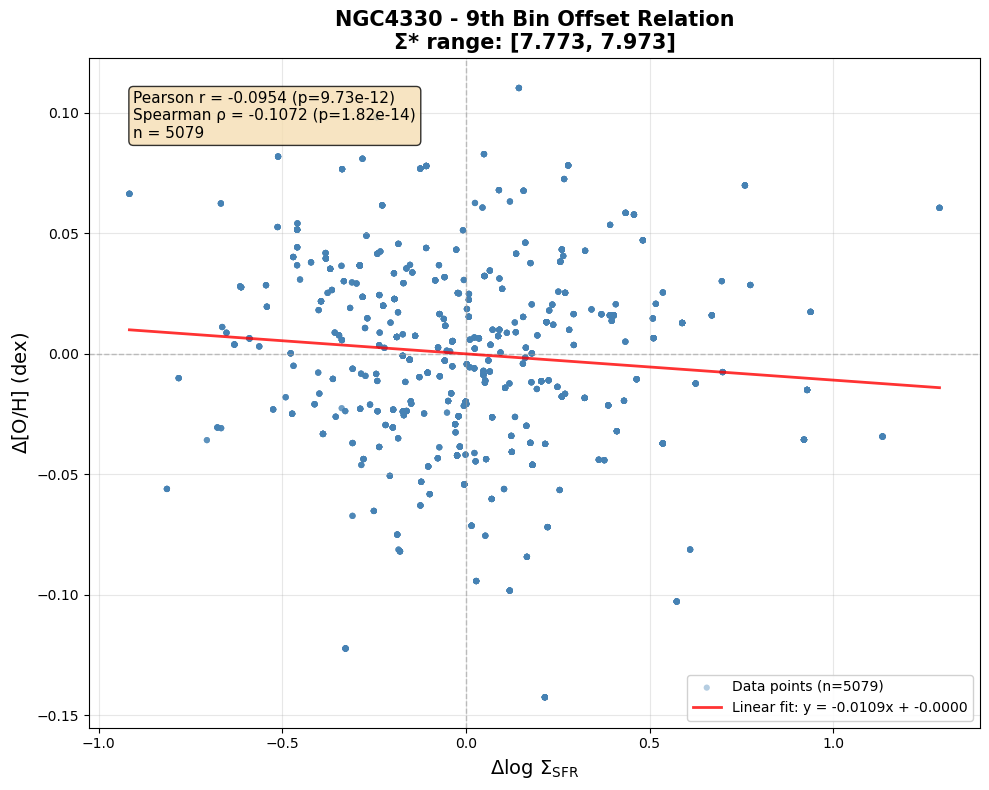


Plot complete!


In [3]:
# ------------------------------------------------------------------
# Calculate correlations for 9th bin using CSV file
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Load the CSV file
csv_filename = 'NGC4330_bin9_data.csv'
df = pd.read_csv(csv_filename)

print(f"Loaded {len(df)} data pairs from '{csv_filename}'")
print(f"{'='*80}\n")

# Extract offset values
x = df['Delta_log_Sigma_SFR'].values
y = df['Delta_O_H'].values

# Remove any NaN or inf values
valid_mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[valid_mask]
y_valid = y[valid_mask]

print(f"Valid data points: {len(x_valid)} out of {len(x)}")
print(f"{'='*80}\n")

# ------------------------------------------------------------------
# 1) Pearson correlation using scipy package
# ------------------------------------------------------------------
pearson_r_pkg, pearson_p_pkg = pearsonr(x_valid, y_valid)

print(f"1) Pearson correlation (scipy package):")
print(f"   r = {pearson_r_pkg:.6f}")
print(f"   p-value = {pearson_p_pkg:.4e}")
print(f"{'='*80}\n")

# ------------------------------------------------------------------
# 2) Pearson correlation using manual equation
# ------------------------------------------------------------------
# Pearson r = cov(X,Y) / (std(X) * std(Y))
# Or equivalently: r = Σ[(xi - x̄)(yi - ȳ)] / sqrt(Σ(xi - x̄)² * Σ(yi - ȳ)²)

x_mean = np.mean(x_valid)
y_mean = np.mean(y_valid)

x_centered = x_valid - x_mean
y_centered = y_valid - y_mean

numerator = np.sum(x_centered * y_centered)
denominator = np.sqrt(np.sum(x_centered**2) * np.sum(y_centered**2))

pearson_r_manual = numerator / denominator

print(f"2) Pearson correlation (manual equation):")
print(f"   r = {pearson_r_manual:.6f}")
print(f"   Difference from package: {abs(pearson_r_manual - pearson_r_pkg):.2e}")
print(f"{'='*80}\n")

# ------------------------------------------------------------------
# 3) Spearman correlation using scipy package
# ------------------------------------------------------------------
spearman_r_pkg, spearman_p_pkg = spearmanr(x_valid, y_valid)

print(f"3) Spearman correlation (scipy package):")
print(f"   ρ = {spearman_r_pkg:.6f}")
print(f"   p-value = {spearman_p_pkg:.4e}")
print(f"{'='*80}\n")

# ------------------------------------------------------------------
# 4) Spearman correlation using manual equation
# ------------------------------------------------------------------
# Spearman ρ = Pearson correlation of rank-transformed data
# Or using the simplified formula: ρ = 1 - (6 * Σd²) / (n * (n² - 1))
# where d = difference between ranks

# Get ranks (using average method for ties)
from scipy.stats import rankdata
x_ranks = rankdata(x_valid, method='average')
y_ranks = rankdata(y_valid, method='average')

# Calculate Spearman using Pearson formula on ranks
x_rank_mean = np.mean(x_ranks)
y_rank_mean = np.mean(y_ranks)

x_rank_centered = x_ranks - x_rank_mean
y_rank_centered = y_ranks - y_rank_mean

rank_numerator = np.sum(x_rank_centered * y_rank_centered)
rank_denominator = np.sqrt(np.sum(x_rank_centered**2) * np.sum(y_rank_centered**2))

spearman_r_manual = rank_numerator / rank_denominator

print(f"4) Spearman correlation (manual equation using rank-based Pearson):")
print(f"   ρ = {spearman_r_manual:.6f}")
print(f"   Difference from package: {abs(spearman_r_manual - spearman_r_pkg):.2e}")
print(f"{'='*80}\n")

# Alternative manual calculation using d² formula (only exact when no ties)
d = x_ranks - y_ranks
n = len(x_valid)
spearman_r_manual_alt = 1 - (6 * np.sum(d**2)) / (n * (n**2 - 1))

print(f"   Alternative ρ (using d² formula): {spearman_r_manual_alt:.6f}")
print(f"   Note: d² formula is exact only when there are no tied ranks")
print(f"{'='*80}\n")

# ------------------------------------------------------------------
# Summary comparison
# ------------------------------------------------------------------
print(f"\nSUMMARY:")
print(f"{'='*80}")
print(f"Correlation Method                          | Value      | p-value")
print(f"{'-'*80}")
print(f"Pearson (scipy package)                     | {pearson_r_pkg:+.6f} | {pearson_p_pkg:.4e}")
print(f"Pearson (manual equation)                   | {pearson_r_manual:+.6f} | N/A")
print(f"Spearman (scipy package)                    | {spearman_r_pkg:+.6f} | {spearman_p_pkg:.4e}")
print(f"Spearman (manual - rank-based Pearson)     | {spearman_r_manual:+.6f} | N/A")
print(f"Spearman (manual - d² formula)              | {spearman_r_manual_alt:+.6f} | N/A")
print(f"{'='*80}\n")

# ------------------------------------------------------------------
# Plot the offset relation
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(x_valid, y_valid, c='steelblue', s=20, alpha=0.4, edgecolors='none', 
           rasterized=True, label=f'Data points (n={len(x_valid)})')

# Add zero reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5, zorder=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5, zorder=1)

# Add linear fit line
z = np.polyfit(x_valid, y_valid, 1)
p = np.poly1d(z)
x_fit = np.linspace(x_valid.min(), x_valid.max(), 100)
ax.plot(x_fit, p(x_fit), 'r-', linewidth=2, alpha=0.8, 
        label=f'Linear fit: y = {z[0]:.4f}x + {z[1]:.4f}')

# Labels and title
ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=14)
ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=14)
ax.set_title(f'NGC4330 - 9th Bin Offset Relation\n' + 
             f'Σ* range: [{df["log_Sigma_M"].min():.3f}, {df["log_Sigma_M"].max():.3f}]',
             fontsize=15, fontweight='bold')

# Grid
ax.grid(True, alpha=0.3)

# Add text box with correlation values
textstr = '\n'.join([
    f'Pearson r = {pearson_r_pkg:.4f} (p={pearson_p_pkg:.2e})',
    f'Spearman ρ = {spearman_r_pkg:.4f} (p={spearman_p_pkg:.2e})',
    f'n = {len(x_valid)}'
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Legend
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"Plot complete!")
print(f"{'='*80}")


## 20251202 
For each galaxy and the stacked case, I equally split into $n$ equal-width bins based on the 95% completeness of $\Sigma_*$. 

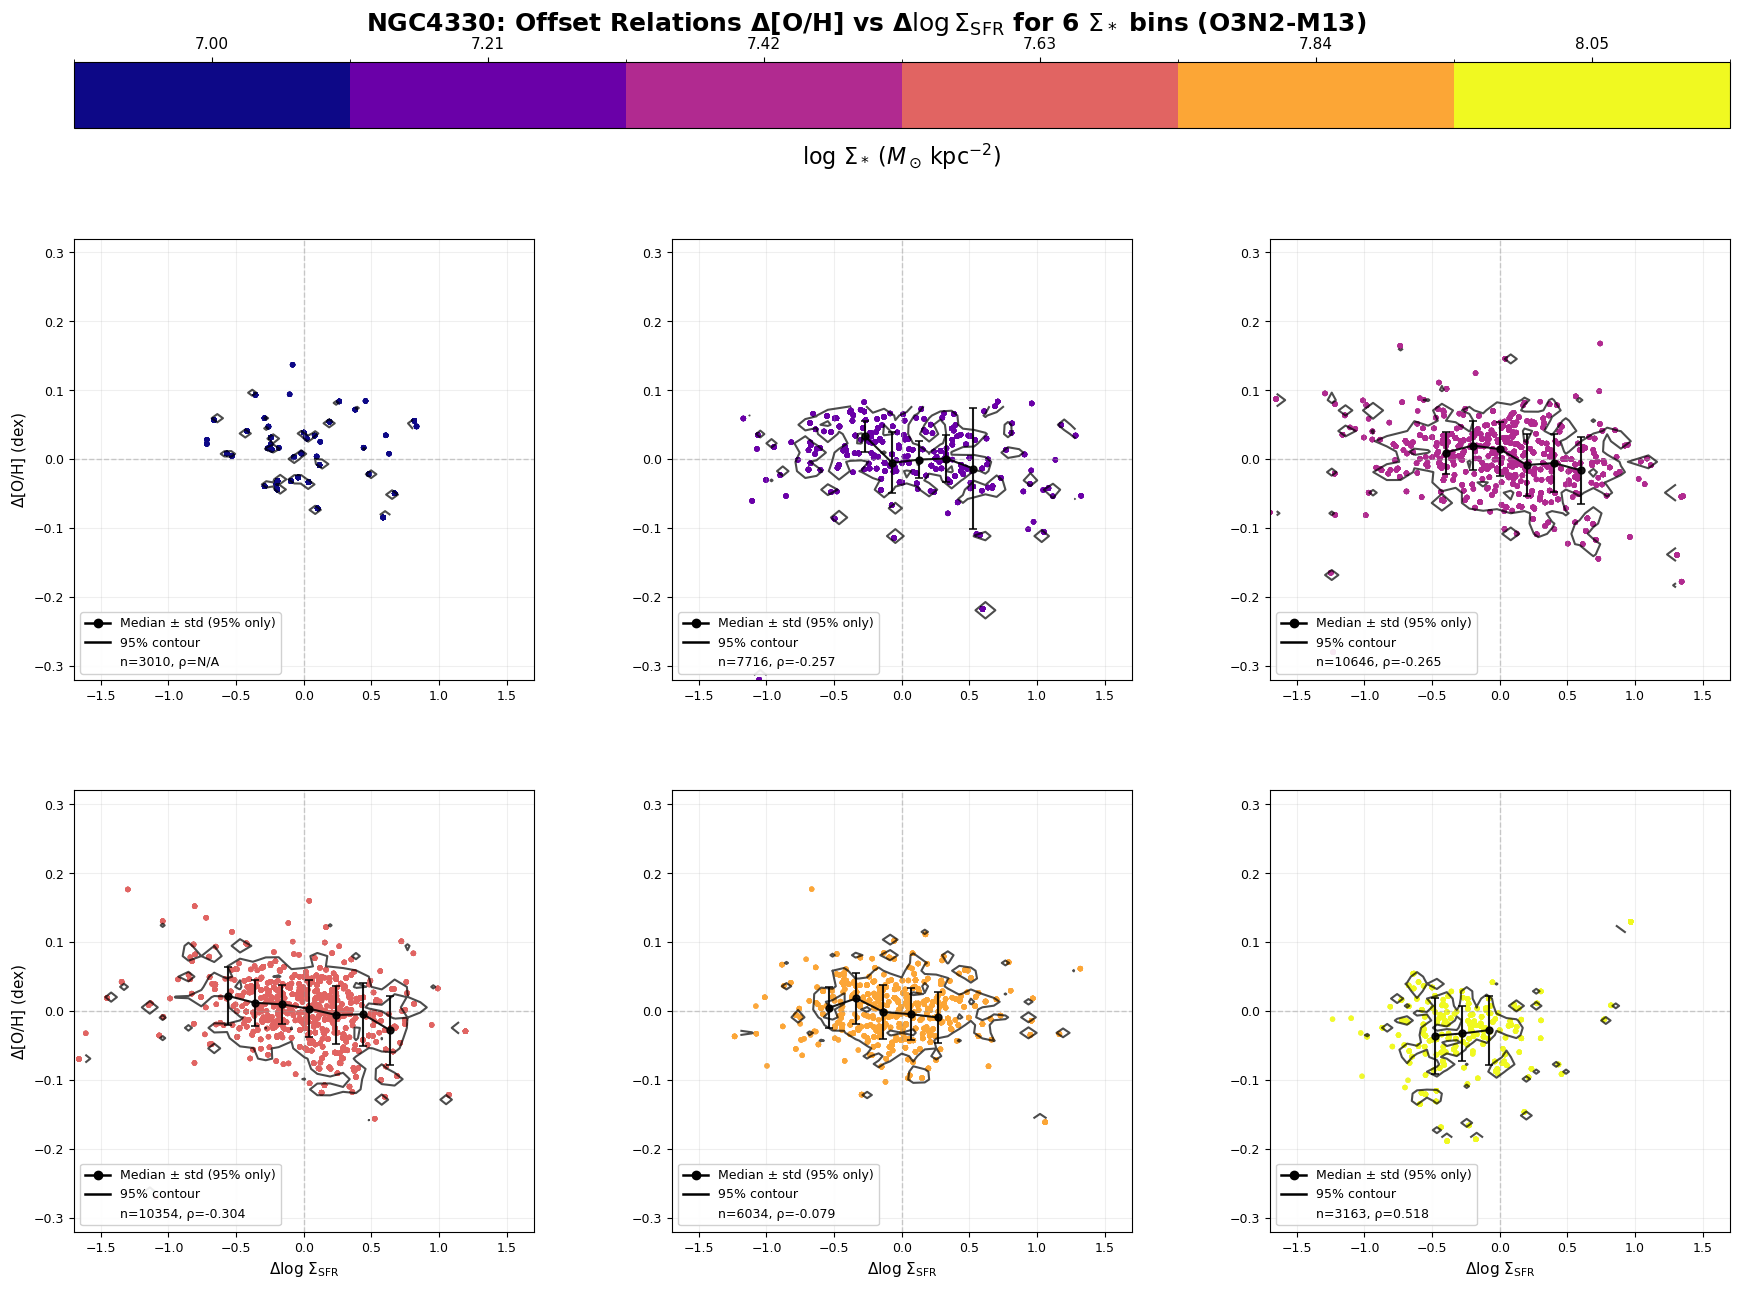


NGC4330: 6-panel offset relation grid complete!
  Number of Σ* bins: 6
  Σ* range (95%): 6.897 to 8.150
  Global Δlog(Σ_SFR) axis limits: ±1.700
  Global Δ[O/H] axis limits: ±0.320


In [11]:
# ------------------------------------------------------------------
# Plot 6 separate offset relations (one per Σ* bin) in 2x3 grid
# With shared colorbar at the top
# Updated: NGC4330, 6 bins, 95% completeness binning, Spearman rho
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins.

    Only keep bins where there are at least `min_unique` unique y-data
    points within the bin. Returns bin centers, medians, stds, and counts.
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        # Require sufficient unique y values in this bin
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 1.  Define 6 Σ* bins based on 95% completeness
    # ------------------------------------------------------------------
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # ------------------------------------------------------------------
    # 2.  Calculate global axis limits (same for all subplots)
    # ------------------------------------------------------------------
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)
            
            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
    
    # ------------------------------------------------------------------
    # 3.  Create 2x3 subplot grid with colorbar at top
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 13))
    
    # Create grid: 1 row for colorbar, 2 rows for subplots
    gs = gridspec.GridSpec(3, 3, figure=fig, 
                          height_ratios=[0.15, 1, 1],
                          hspace=0.35, wspace=0.3,
                          top=0.95, bottom=0.05, left=0.06, right=0.98)
    
    # Create colorbar axis at the top (spanning all columns)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Create 6 subplots in 2x3 grid
    axes = []
    for row in range(2):
        for col in range(3):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)
    
    # ------------------------------------------------------------------
    # 4.  Plot each Σ* bin in its own subplot
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]
        
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        n_pixels = np.sum(bin_mask)
        
        if n_pixels > 0:
            # Get values in this bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            # Calculate offsets WITHIN this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)
            
            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean
            
            # Validity mask in this bin
            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            
            # Get color for this bin
            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
            
            # Scatter plot (all valid points in bin)
            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr], 
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)
            
            # ------------------------------------------------------------------
            # Calculate 95% contour and mask
            # ------------------------------------------------------------------
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True
            
            # ------------------------------------------------------------------
            # Calculate median trend using only points inside 95% contour
            # and requiring at least `min_unique` unique y-values per bin
            # ------------------------------------------------------------------
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size > 0
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)
            
            # ------------------------------------------------------------------
            # Spearman rho: only for points inside 95% contour and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                spearman_rho, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                r_label = f'ρ={spearman_rho:.3f}'
            else:
                spearman_rho, spearman_p = np.nan, np.nan
                r_label = 'ρ=N/A'
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            
            # Set symmetric limits (global)
            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            
            # Grid
            ax.grid(True, alpha=0.2)
            
            # Legend entries for each subplot: median, contour, n and r
            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)
            
            # Labels (only on left and bottom edges)
            if i % 3 == 0:  # Left column
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            if i >= 3:  # Bottom row
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)
            
            ax.tick_params(labelsize=9)
        else:
            # No data in this bin
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # ------------------------------------------------------------------
    # 5.  Create horizontal colorbar at the top
    # ------------------------------------------------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')
    
    fig.suptitle(rf'{gal}: Offset Relations Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ for {n_bins} $\Sigma_*$ bins ({indicator_name})',
                fontsize=18, y=0.99, fontweight='bold')
    
    plt.show()
    
    print(f"\n{gal}: {n_bins}-panel offset relation grid complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")


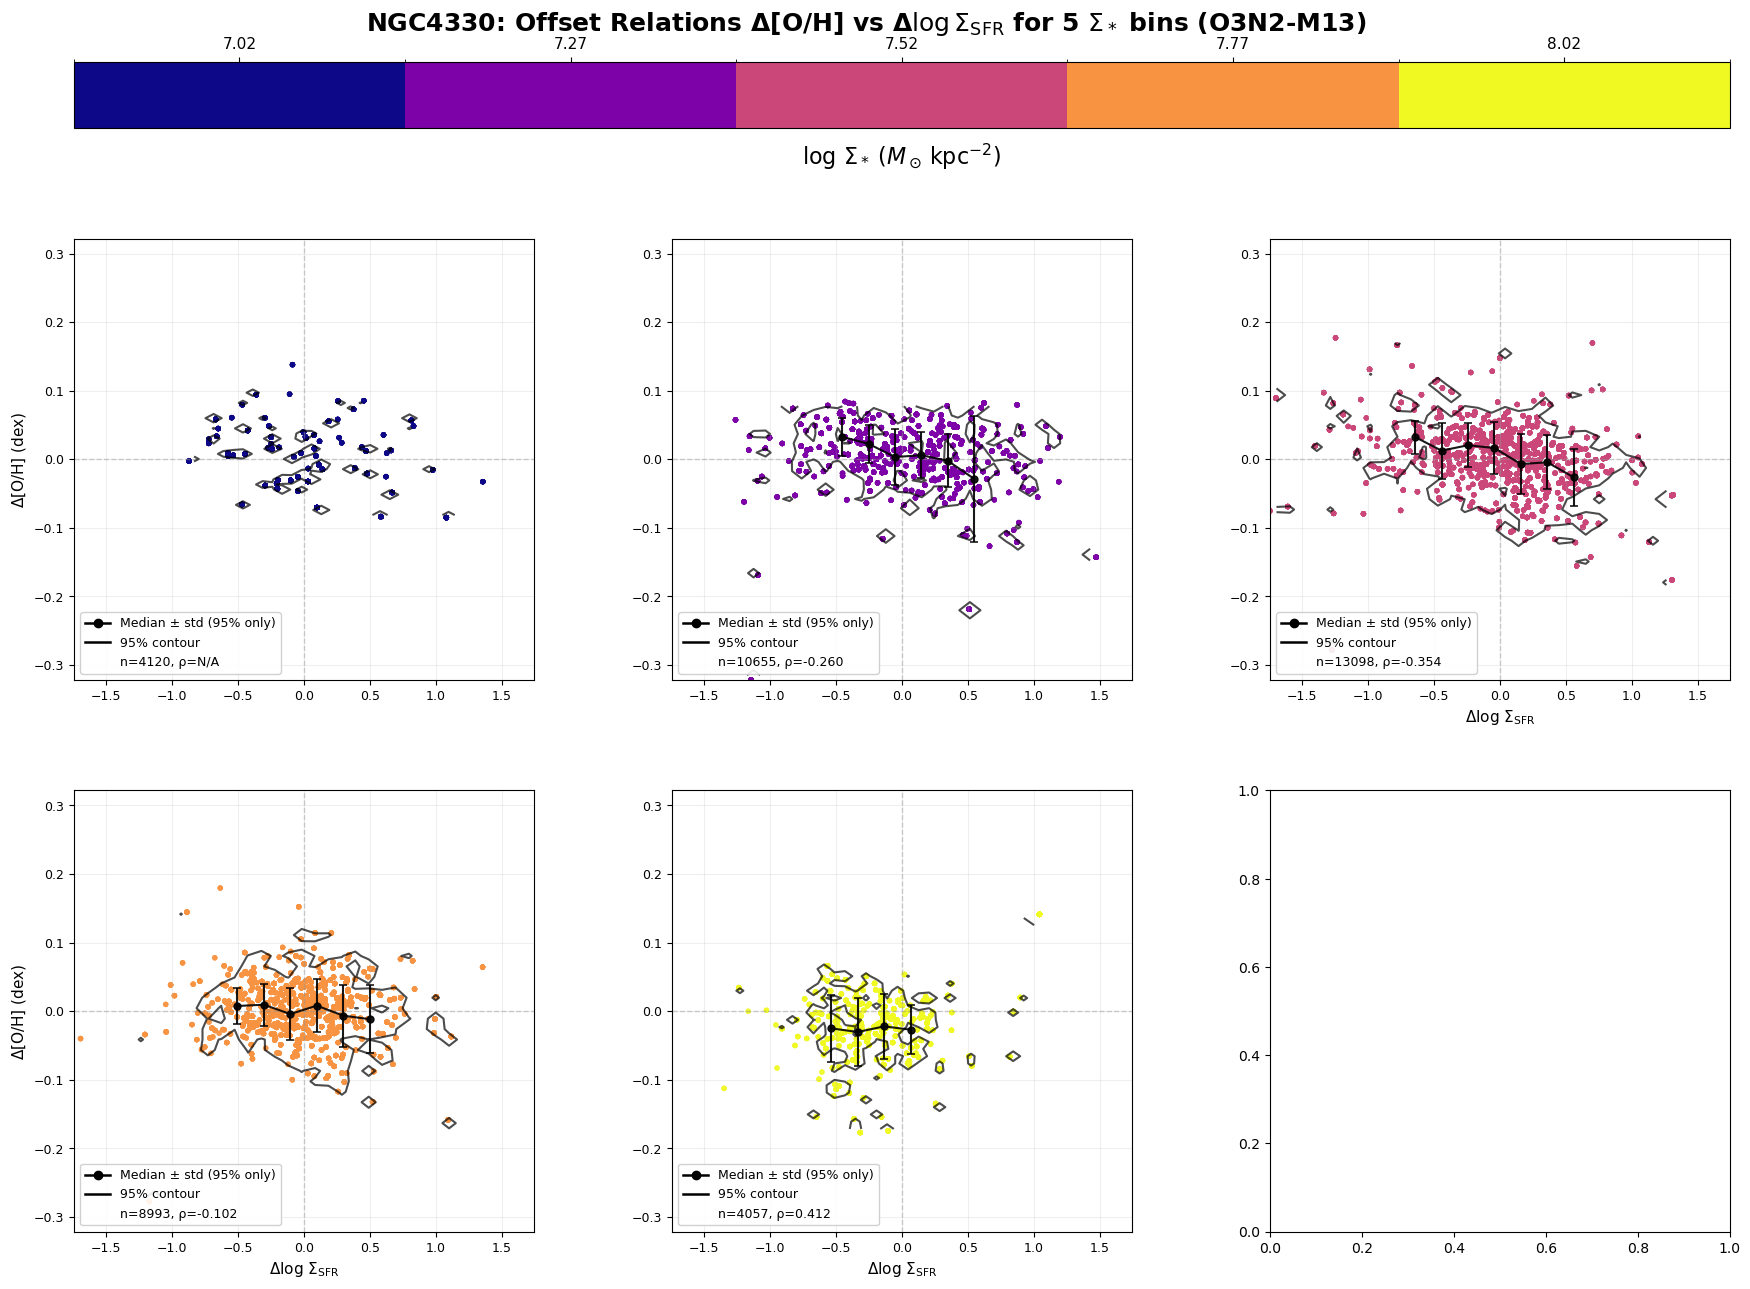


NGC4330: 5-panel offset relation grid complete!
  Number of Σ* bins: 5
  Σ* range (95%): 6.897 to 8.150
  Global Δlog(Σ_SFR) axis limits: ±1.740
  Global Δ[O/H] axis limits: ±0.322


In [12]:
# ------------------------------------------------------------------
# Plot 5 separate offset relations (one per Σ* bin) in 2x3 grid
# With shared colorbar at the top
# Updated: NGC4330, 5 bins, 95% completeness binning, Spearman rho
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins.

    Only keep bins where there are at least `min_unique` unique y-data
    points within the bin. Returns bin centers, medians, stds, and counts.
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        # Require sufficient unique y values in this bin
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 1.  Define 5 Σ* bins based on 95% completeness
    # ------------------------------------------------------------------
    n_bins = 5
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # ------------------------------------------------------------------
    # 2.  Calculate global axis limits (same for all subplots)
    # ------------------------------------------------------------------
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)
            
            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
    
    # ------------------------------------------------------------------
    # 3.  Create 2x3 subplot grid with colorbar at top
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 13))
    
    # Create grid: 1 row for colorbar, 2 rows for subplots
    gs = gridspec.GridSpec(3, 3, figure=fig, 
                          height_ratios=[0.15, 1, 1],
                          hspace=0.35, wspace=0.3,
                          top=0.95, bottom=0.05, left=0.06, right=0.98)
    
    # Create colorbar axis at the top (spanning all columns)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Create 6 subplots in 2x3 grid
    axes = []
    for row in range(2):
        for col in range(3):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)
    
    # ------------------------------------------------------------------
    # 4.  Plot each Σ* bin in its own subplot
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]
        
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        n_pixels = np.sum(bin_mask)
        
        if n_pixels > 0:
            # Get values in this bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            # Calculate offsets WITHIN this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)
            
            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean
            
            # Validity mask in this bin
            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            
            # Get color for this bin
            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
            
            # Scatter plot (all valid points in bin)
            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr], 
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)
            
            # ------------------------------------------------------------------
            # Calculate 95% contour and mask
            # ------------------------------------------------------------------
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True
            
            # ------------------------------------------------------------------
            # Calculate median trend using only points inside 95% contour
            # and requiring at least `min_unique` unique y-values per bin
            # ------------------------------------------------------------------
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size > 0
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)
            
            # ------------------------------------------------------------------
            # Spearman rho: only for points inside 95% contour and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                spearman_rho, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                r_label = f'ρ={spearman_rho:.3f}'
            else:
                spearman_rho, spearman_p = np.nan, np.nan
                r_label = 'ρ=N/A'
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            
            # Set symmetric limits (global)
            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            
            # Grid
            ax.grid(True, alpha=0.2)
            
            # Legend entries for each subplot: median, contour, n and r
            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)
            
            # Labels (only on left and bottom edges)
            if i % 3 == 0:  # Left column
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            
            # x-label on bottom-most existing plot in each column
            # For 5 bins in 2x3 grid: indices 0,1,2 (row 0) and 3,4 (row 1)
            # Bottom plots are 3, 4, and 2 (since 5 is empty)
            if i in [2, 3, 4]:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)
            
            ax.tick_params(labelsize=9)
        else:
            # No data in this bin
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # ------------------------------------------------------------------
    # 5.  Create horizontal colorbar at the top
    # ------------------------------------------------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')
    
    fig.suptitle(rf'{gal}: Offset Relations Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ for {n_bins} $\Sigma_*$ bins ({indicator_name})',
                fontsize=18, y=0.99, fontweight='bold')
    
    plt.show()
    
    print(f"\n{gal}: {n_bins}-panel offset relation grid complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")


Checking Bin 6 (Highest Mass Bin)
Mass range: 7.941 - 8.150
Total valid points in bin: 3163
Points inside 95% contour: 3009
Spearman rho (ALL points): 0.499 (p=9.170e-199)
Spearman rho (Contour points): 0.518 (p=7.629e-206)
X range (SFR offset): -1.236 to 0.967
Y range (OH offset): -0.189 to 0.130


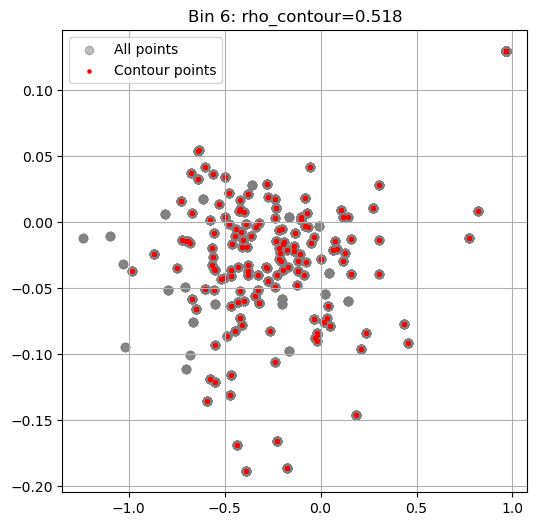

In [25]:
# Verification for the highest mass bin of NGC4330
from pathlib import Path
from astropy.io import fits
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            raise KeyError(f"No O3N2 metallicity extension found.")
    return sigM, sigSFR, oh_map

gal = 'NGC4330'
sigM, sigSFR, oh_o3n2_map = load_maps(gal)

valid_sfr = np.isfinite(sigSFR)
valid_oh = np.isfinite(oh_o3n2_map)
valid_sigM = np.isfinite(sigM)
valid_all = valid_sfr & valid_oh & valid_sigM

n_bins = 6
sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

# Highest mass bin (index 5)
i = 5
bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all

print(f"Checking Bin {i+1} (Highest Mass Bin)")
print(f"Mass range: {sigmaM_bin_edges[i]:.3f} - {sigmaM_bin_edges[i+1]:.3f}")

if np.sum(bin_mask) > 0:
    sfr_bin = sigSFR[bin_mask]
    oh_bin = oh_o3n2_map[bin_mask]
    
    sfr_offset = sfr_bin - np.mean(sfr_bin)
    oh_offset = oh_bin - np.mean(oh_bin)
    
    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    n_points = np.sum(valid_corr)
    print(f"Total valid points in bin: {n_points}")
    
    # 95% Contour Logic
    contour_mask = np.zeros_like(valid_corr, dtype=bool)
    if n_points > 20:
        try:
            H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                               bins=30, density=True)
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

            x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
            y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1
            x_idx = np.clip(x_idx, 0, H.shape[0]-1)
            y_idx = np.clip(y_idx, 0, H.shape[1]-1)

            inside = H[x_idx, y_idx] >= threshold_95
            contour_mask[valid_corr] = inside
        except Exception as e:
            print(f"Contour calculation failed: {e}")
            contour_mask[:] = True
    else:
        contour_mask[:] = True
        
    n_contour = np.sum(contour_mask & valid_corr)
    print(f"Points inside 95% contour: {n_contour}")
    
    # Spearman
    rho_all, p_all = spearmanr(sfr_offset[valid_corr], oh_offset[valid_corr])
    print(f"Spearman rho (ALL points): {rho_all:.3f} (p={p_all:.3e})")
    
    rho_contour, p_contour = spearmanr(sfr_offset[contour_mask & valid_corr], oh_offset[contour_mask & valid_corr])
    print(f"Spearman rho (Contour points): {rho_contour:.3f} (p={p_contour:.3e})")
    
    # Check for outliers
    x_data = sfr_offset[valid_corr]
    y_data = oh_offset[valid_corr]
    print(f"X range (SFR offset): {np.min(x_data):.3f} to {np.max(x_data):.3f}")
    print(f"Y range (OH offset): {np.min(y_data):.3f} to {np.max(y_data):.3f}")
    
    # Plot to visualize
    plt.figure(figsize=(6, 6))
    plt.scatter(x_data, y_data, c='gray', alpha=0.5, label='All points')
    plt.scatter(sfr_offset[contour_mask & valid_corr], oh_offset[contour_mask & valid_corr], 
                c='red', s=5, label='Contour points')
    plt.title(f"Bin {i+1}: rho_contour={rho_contour:.3f}")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No data in this bin.")

Checking Bin 6 (Highest Mass Bin)
Mass range: 7.941 - 8.150
Total valid points in bin: 3163
Points inside 68% contour: 2213
Spearman rho (ALL points): 0.499 (p=9.170e-199)
Spearman rho (Contour points): 0.640 (p=8.797e-256)
X range (SFR offset): -1.236 to 0.967
Y range (OH offset): -0.189 to 0.130


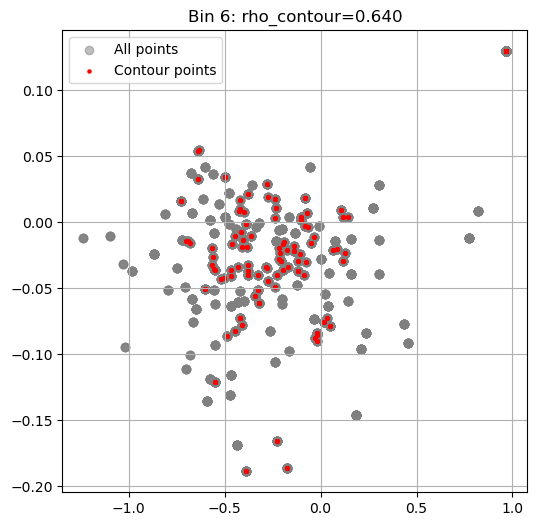

In [9]:
# Verification for the highest mass bin of NGC4330
from pathlib import Path
from astropy.io import fits
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            raise KeyError(f"No O3N2 metallicity extension found.")
    return sigM, sigSFR, oh_map

gal = 'NGC4330'
sigM, sigSFR, oh_o3n2_map = load_maps(gal)

valid_sfr = np.isfinite(sigSFR)
valid_oh = np.isfinite(oh_o3n2_map)
valid_sigM = np.isfinite(sigM)
valid_all = valid_sfr & valid_oh & valid_sigM

n_bins = 6
sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

# Highest mass bin (index 5)
i = 5
bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all

print(f"Checking Bin {i+1} (Highest Mass Bin)")
print(f"Mass range: {sigmaM_bin_edges[i]:.3f} - {sigmaM_bin_edges[i+1]:.3f}")

if np.sum(bin_mask) > 0:
    sfr_bin = sigSFR[bin_mask]
    oh_bin = oh_o3n2_map[bin_mask]
    
    sfr_offset = sfr_bin - np.mean(sfr_bin)
    oh_offset = oh_bin - np.mean(oh_bin)
    
    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    n_points = np.sum(valid_corr)
    print(f"Total valid points in bin: {n_points}")
    
    # 68% Contour Logic
    contour_mask = np.zeros_like(valid_corr, dtype=bool)
    if n_points > 20:
        try:
            H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                               bins=30, density=True)
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            threshold_68 = H_sorted[np.where(H_cumsum >= 0.68)[0][0]]

            x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
            y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1
            x_idx = np.clip(x_idx, 0, H.shape[0]-1)
            y_idx = np.clip(y_idx, 0, H.shape[1]-1)

            inside = H[x_idx, y_idx] >= threshold_68
            contour_mask[valid_corr] = inside
        except Exception as e:
            print(f"Contour calculation failed: {e}")
            contour_mask[:] = True
    else:
        contour_mask[:] = True
        
    n_contour = np.sum(contour_mask & valid_corr)
    print(f"Points inside 68% contour: {n_contour}")
    
    # Spearman
    rho_all, p_all = spearmanr(sfr_offset[valid_corr], oh_offset[valid_corr])
    print(f"Spearman rho (ALL points): {rho_all:.3f} (p={p_all:.3e})")
    
    rho_contour, p_contour = spearmanr(sfr_offset[contour_mask & valid_corr], oh_offset[contour_mask & valid_corr])
    print(f"Spearman rho (Contour points): {rho_contour:.3f} (p={p_contour:.3e})")
    
    # Check for outliers
    x_data = sfr_offset[valid_corr]
    y_data = oh_offset[valid_corr]
    print(f"X range (SFR offset): {np.min(x_data):.3f} to {np.max(x_data):.3f}")
    print(f"Y range (OH offset): {np.min(y_data):.3f} to {np.max(y_data):.3f}")
    
    # Plot to visualize
    plt.figure(figsize=(6, 6))
    plt.scatter(x_data, y_data, c='gray', alpha=0.5, label='All points')
    plt.scatter(sfr_offset[contour_mask & valid_corr], oh_offset[contour_mask & valid_corr], 
                c='red', s=5, label='Contour points')
    plt.title(f"Bin {i+1}: rho_contour={rho_contour:.3f}")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No data in this bin.")

Checking Bin 6 (Highest Mass Bin)
Mass range: 7.941 - 8.150
Total valid points in bin: 3163
Points inside 95% contour: 3029
Spearman rho (ALL points): 0.499 (p=9.170e-199)
Spearman rho (Contour points): 0.514 (p=1.400e-203)
X range (SFR offset): -1.236 to 0.967
Y range (OH offset): -0.189 to 0.130


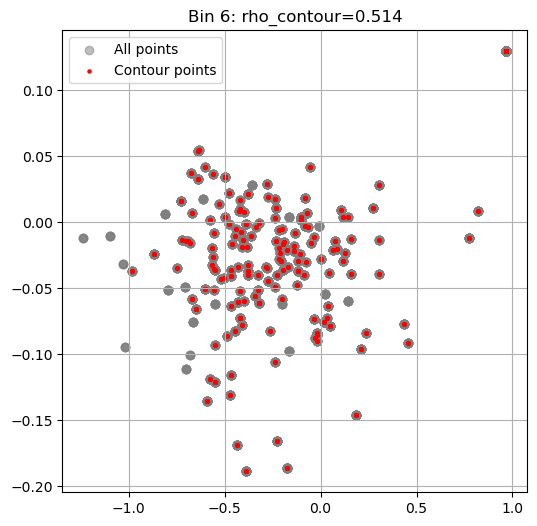

In [3]:
# Verification for the highest mass bin of NGC4330
from pathlib import Path
from astropy.io import fits
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            raise KeyError(f"No O3N2 metallicity extension found.")
    return sigM, sigSFR, oh_map

gal = 'NGC4330'
sigM, sigSFR, oh_o3n2_map = load_maps(gal)

valid_sfr = np.isfinite(sigSFR)
valid_oh = np.isfinite(oh_o3n2_map)
valid_sigM = np.isfinite(sigM)
valid_all = valid_sfr & valid_oh & valid_sigM

n_bins = 6
sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

# Highest mass bin (index 5)
i = 5
bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all

print(f"Checking Bin {i+1} (Highest Mass Bin)")
print(f"Mass range: {sigmaM_bin_edges[i]:.3f} - {sigmaM_bin_edges[i+1]:.3f}")

if np.sum(bin_mask) > 0:
    sfr_bin = sigSFR[bin_mask]
    oh_bin = oh_o3n2_map[bin_mask]
    
    sfr_offset = sfr_bin - np.mean(sfr_bin)
    oh_offset = oh_bin - np.mean(oh_bin)
    
    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    n_points = np.sum(valid_corr)
    print(f"Total valid points in bin: {n_points}")
    
    # 95% Contour Logic (based on 95% of unique data points)
    contour_mask = np.zeros_like(valid_corr, dtype=bool)
    if n_points > 20:
        try:
            H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                               bins=30)
            
            # Map each data point to its histogram bin
            x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
            y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1
            x_idx = np.clip(x_idx, 0, H.shape[0]-1)
            y_idx = np.clip(y_idx, 0, H.shape[1]-1)
            
            # Get density values for each point
            point_densities = H[x_idx, y_idx]
            
            # Sort densities and find threshold for 95% of unique points
            sorted_densities = np.sort(point_densities)[::-1]
            n_unique_95 = int(0.95 * len(sorted_densities))
            threshold_95 = sorted_densities[n_unique_95]
            
            # Points inside contour are those with density >= threshold
            inside = point_densities >= threshold_95
            contour_mask[valid_corr] = inside
        except Exception as e:
            print(f"Contour calculation failed: {e}")
            contour_mask[:] = True
    else:
        contour_mask[:] = True
        
    n_contour = np.sum(contour_mask & valid_corr)
    print(f"Points inside 95% contour: {n_contour}")
    
    # Spearman
    rho_all, p_all = spearmanr(sfr_offset[valid_corr], oh_offset[valid_corr])
    print(f"Spearman rho (ALL points): {rho_all:.3f} (p={p_all:.3e})")
    
    rho_contour, p_contour = spearmanr(sfr_offset[contour_mask & valid_corr], oh_offset[contour_mask & valid_corr])
    print(f"Spearman rho (Contour points): {rho_contour:.3f} (p={p_contour:.3e})")
    
    # Check for outliers
    x_data = sfr_offset[valid_corr]
    y_data = oh_offset[valid_corr]
    print(f"X range (SFR offset): {np.min(x_data):.3f} to {np.max(x_data):.3f}")
    print(f"Y range (OH offset): {np.min(y_data):.3f} to {np.max(y_data):.3f}")
    
    # Plot to visualize
    plt.figure(figsize=(6, 6))
    plt.scatter(x_data, y_data, c='gray', alpha=0.5, label='All points')
    plt.scatter(sfr_offset[contour_mask & valid_corr], oh_offset[contour_mask & valid_corr], 
                c='red', s=5, label='Contour points')
    plt.title(f"Bin {i+1}: rho_contour={rho_contour:.3f}")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No data in this bin.")

Checking Bin 6 (Highest Mass Bin)
Mass range: 7.726 - 7.832
Total valid points in bin: 3580
Points inside 95% contour: 3431
Spearman rho (ALL points): -0.094 (p=2.011e-08)
Spearman rho (Contour points): -0.114 (p=2.513e-11)
X range (SFR offset): -1.220 to 1.335
Y range (OH offset): -0.160 to 0.104


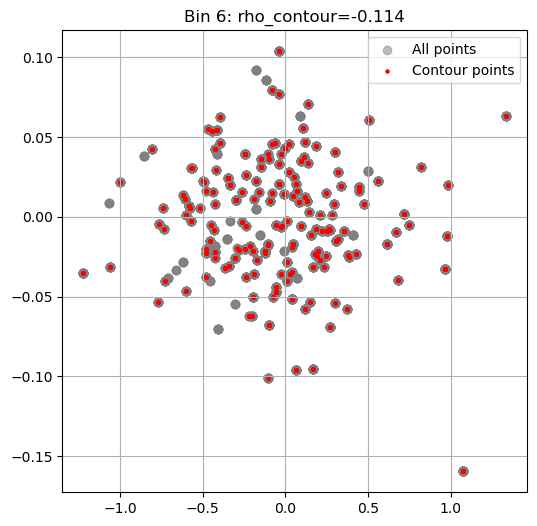

In [10]:
# Verification for the highest mass bin of NGC4330
from pathlib import Path
from astropy.io import fits
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            raise KeyError(f"No O3N2 metallicity extension found.")
    return sigM, sigSFR, oh_map

gal = 'NGC4330'
sigM, sigSFR, oh_o3n2_map = load_maps(gal)

valid_sfr = np.isfinite(sigSFR)
valid_oh = np.isfinite(oh_o3n2_map)
valid_sigM = np.isfinite(sigM)
valid_all = valid_sfr & valid_oh & valid_sigM

n_bins = 6
sigmaM_min = np.nanpercentile(sigM[valid_all], 16)
sigmaM_max = np.nanpercentile(sigM[valid_all], 84)
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

# Highest mass bin (index 5)
i = 5
bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all

print(f"Checking Bin {i+1} (Highest Mass Bin)")
print(f"Mass range: {sigmaM_bin_edges[i]:.3f} - {sigmaM_bin_edges[i+1]:.3f}")

if np.sum(bin_mask) > 0:
    sfr_bin = sigSFR[bin_mask]
    oh_bin = oh_o3n2_map[bin_mask]
    
    sfr_offset = sfr_bin - np.mean(sfr_bin)
    oh_offset = oh_bin - np.mean(oh_bin)
    
    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    n_points = np.sum(valid_corr)
    print(f"Total valid points in bin: {n_points}")
    
    # 95% Contour Logic (based on 95% of unique data points)
    contour_mask = np.zeros_like(valid_corr, dtype=bool)
    if n_points > 20:
        try:
            H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                               bins=30)
            
            # Map each data point to its histogram bin
            x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
            y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1
            x_idx = np.clip(x_idx, 0, H.shape[0]-1)
            y_idx = np.clip(y_idx, 0, H.shape[1]-1)
            
            # Get density values for each point
            point_densities = H[x_idx, y_idx]
            
            # Sort densities and find threshold for 95% of unique points
            sorted_densities = np.sort(point_densities)[::-1]
            n_unique_95 = int(0.95 * len(sorted_densities))
            threshold_95 = sorted_densities[n_unique_95]
            
            # Points inside contour are those with density >= threshold
            inside = point_densities >= threshold_95
            contour_mask[valid_corr] = inside
        except Exception as e:
            print(f"Contour calculation failed: {e}")
            contour_mask[:] = True
    else:
        contour_mask[:] = True
        
    n_contour = np.sum(contour_mask & valid_corr)
    print(f"Points inside 95% contour: {n_contour}")
    
    # Spearman
    rho_all, p_all = spearmanr(sfr_offset[valid_corr], oh_offset[valid_corr])
    print(f"Spearman rho (ALL points): {rho_all:.3f} (p={p_all:.3e})")
    
    rho_contour, p_contour = spearmanr(sfr_offset[contour_mask & valid_corr], oh_offset[contour_mask & valid_corr])
    print(f"Spearman rho (Contour points): {rho_contour:.3f} (p={p_contour:.3e})")
    
    # Check for outliers
    x_data = sfr_offset[valid_corr]
    y_data = oh_offset[valid_corr]
    print(f"X range (SFR offset): {np.min(x_data):.3f} to {np.max(x_data):.3f}")
    print(f"Y range (OH offset): {np.min(y_data):.3f} to {np.max(y_data):.3f}")
    
    # Plot to visualize
    plt.figure(figsize=(6, 6))
    plt.scatter(x_data, y_data, c='gray', alpha=0.5, label='All points')
    plt.scatter(sfr_offset[contour_mask & valid_corr], oh_offset[contour_mask & valid_corr], 
                c='red', s=5, label='Contour points')
    plt.title(f"Bin {i+1}: rho_contour={rho_contour:.3f}")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No data in this bin.")

Checking Bin 6 (Highest Mass Bin)
Mass range: 7.941 - 8.150
Total valid points in bin: 3163
95% distance threshold: 0.976
Points inside 95% contour: 3134
Spearman rho (Inner 95% points): 0.501 (p=7.766e-199)
X range (SFR offset): -0.868 to 0.967
Y range (OH offset): -0.189 to 0.130


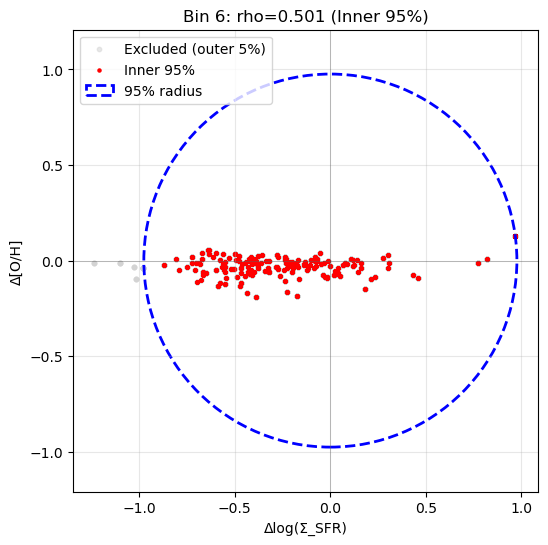

In [16]:
# Verification for the highest mass bin of NGC4330
from pathlib import Path
from astropy.io import fits
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            raise KeyError(f"No O3N2 metallicity extension found.")
    return sigM, sigSFR, oh_map

gal = 'NGC4330'
sigM, sigSFR, oh_o3n2_map = load_maps(gal)

valid_sfr = np.isfinite(sigSFR)
valid_oh = np.isfinite(oh_o3n2_map)
valid_sigM = np.isfinite(sigM)
valid_all = valid_sfr & valid_oh & valid_sigM

n_bins = 6
sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

# Highest mass bin (index 5)
i = 5
bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all

print(f"Checking Bin {i+1} (Highest Mass Bin)")
print(f"Mass range: {sigmaM_bin_edges[i]:.3f} - {sigmaM_bin_edges[i+1]:.3f}")

if np.sum(bin_mask) > 0:
    sfr_bin = sigSFR[bin_mask]
    oh_bin = oh_o3n2_map[bin_mask]
    
    sfr_offset = sfr_bin - np.mean(sfr_bin)
    oh_offset = oh_bin - np.mean(oh_bin)
    
    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    n_points = np.sum(valid_corr)
    print(f"Total valid points in bin: {n_points}")
    
    # Select inner 95% of data in 2D space (remove 5% most distant outliers)
    sfr_valid = sfr_offset[valid_corr]
    oh_valid = oh_offset[valid_corr]
    
    # Calculate distance from center (0, 0) for each point
    distances = np.sqrt(sfr_valid**2 + oh_valid**2)
    
    # Find the 95th percentile distance
    distance_threshold = np.percentile(distances, 95)
    print(f"95% distance threshold: {distance_threshold:.3f}")
    
    # Create mask for points within the 95% radius
    inner_95_indices = distances <= distance_threshold
    
    # Map back to the full valid_corr mask
    contour_mask = np.zeros_like(valid_corr, dtype=bool)
    contour_mask[valid_corr] = inner_95_indices
    
    n_contour = np.sum(contour_mask)
    print(f"Points inside 95% contour: {n_contour}")
    
    # Update valid_corr to only include inner 95% points
    valid_corr = contour_mask
    
    # Spearman correlation on inner 95% data
    rho_contour, p_contour = spearmanr(sfr_offset[valid_corr], oh_offset[valid_corr])
    print(f"Spearman rho (Inner 95% points): {rho_contour:.3f} (p={p_contour:.3e})")
    
    # Check data ranges
    x_data = sfr_offset[valid_corr]
    y_data = oh_offset[valid_corr]
    print(f"X range (SFR offset): {np.min(x_data):.3f} to {np.max(x_data):.3f}")
    print(f"Y range (OH offset): {np.min(y_data):.3f} to {np.max(y_data):.3f}")
    
    # Plot to visualize
    plt.figure(figsize=(6, 6))
    # Plot all points
    plt.scatter(sfr_offset[np.isfinite(sfr_offset) & np.isfinite(oh_offset)], 
                oh_offset[np.isfinite(sfr_offset) & np.isfinite(oh_offset)], 
                c='lightgray', alpha=0.5, s=10, label='Excluded (outer 5%)')
    # Plot inner 95% points
    plt.scatter(x_data, y_data, c='red', s=5, label='Inner 95%')
    # Draw the 95% contour circle
    circle = plt.Circle((0, 0), distance_threshold, fill=False, color='blue', 
                        linestyle='--', linewidth=2, label='95% radius')
    plt.gca().add_patch(circle)
    plt.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.title(f"Bin {i+1}: rho={rho_contour:.3f} (Inner 95%)")
    plt.xlabel('Δlog(Σ_SFR)')
    plt.ylabel('Δ[O/H]')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()
else:
    print("No data in this bin.")

Checking Bin 6 (Highest Mass Bin)
Mass range: 7.941 - 8.150
Total valid points in bin: 3163
68% distance threshold: 0.637
Points inside 68% contour: 2161
Spearman rho (Inner 68% points): -0.005 (p=8.229e-01)
X range (SFR offset): -0.635 to 0.456
Y range (OH offset): -0.189 to 0.055


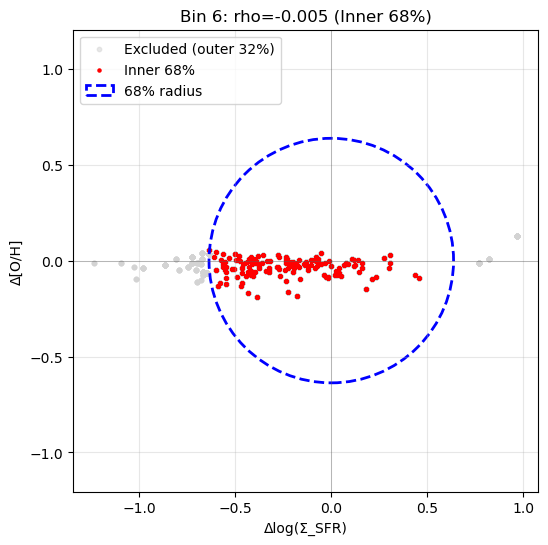

In [8]:
# Verification for the highest mass bin of NGC4330
from pathlib import Path
from astropy.io import fits
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            raise KeyError(f"No O3N2 metallicity extension found.")
    return sigM, sigSFR, oh_map

gal = 'NGC4330'
sigM, sigSFR, oh_o3n2_map = load_maps(gal)

valid_sfr = np.isfinite(sigSFR)
valid_oh = np.isfinite(oh_o3n2_map)
valid_sigM = np.isfinite(sigM)
valid_all = valid_sfr & valid_oh & valid_sigM

n_bins = 6
# Use unique values for percentile calculation
sigM_unique = np.unique(sigM[valid_all])
sigmaM_min = np.percentile(sigM_unique, 2.5)
sigmaM_max = np.percentile(sigM_unique, 97.5)
print(f"Unique sigM values: {len(sigM_unique)}")
print(f"SigmaM range (2.5-97.5%ile of unique): [{sigmaM_min:.3f}, {sigmaM_max:.3f}]")
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

# Highest mass bin (index 5)
i = 5
bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all

print(f"\nChecking Bin {i+1} (Highest Mass Bin)")
print(f"Mass range: {sigmaM_bin_edges[i]:.3f} - {sigmaM_bin_edges[i+1]:.3f}")

if np.sum(bin_mask) > 0:
    sfr_bin = sigSFR[bin_mask]
    oh_bin = oh_o3n2_map[bin_mask]
    
    sfr_offset = sfr_bin - np.mean(sfr_bin)
    oh_offset = oh_bin - np.mean(oh_bin)
    
    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    n_points_total = np.sum(valid_corr)
    print(f"Total valid points in bin: {n_points_total}")
    
    # Select inner 95% of data in 2D space (remove 5% most distant outliers)
    sfr_valid = sfr_offset[valid_corr]
    oh_valid = oh_offset[valid_corr]
    
    # Calculate distance from center (0, 0) for each point
    distances = np.sqrt(sfr_valid**2 + oh_valid**2)
    
    # Find the 95th percentile distance
    distance_threshold = np.percentile(distances, 95)
    print(f"95% distance threshold: {distance_threshold:.3f}")
    
    # Create mask for points within the 95% radius
    inner_95_indices = distances <= distance_threshold
    
    # Map back to the full valid_corr mask
    contour_mask = np.zeros_like(valid_corr, dtype=bool)
    contour_mask[valid_corr] = inner_95_indices
    
    n_contour = np.sum(contour_mask)
    print(f"Points inside 95% contour: {n_contour}")
    
    # Spearman correlation on inner 95% data
    rho_contour, p_contour = spearmanr(sfr_offset[contour_mask], oh_offset[contour_mask])
    print(f"Spearman rho (Inner 95% points): {rho_contour:.3f} (p={p_contour:.3e})")
    
    # Check data ranges
    x_used = sfr_offset[contour_mask]
    y_used = oh_offset[contour_mask]
    print(f"X range (SFR offset, used): {np.min(x_used):.3f} to {np.max(x_used):.3f}")
    print(f"Y range (OH offset, used): {np.min(y_used):.3f} to {np.max(y_used):.3f}")
    
    # Plot to visualize
    plt.figure(figsize=(6, 6))
    # Plot excluded points (gray)
    excluded_mask = valid_corr & ~contour_mask
    if np.sum(excluded_mask) > 0:
        plt.scatter(sfr_offset[excluded_mask], oh_offset[excluded_mask], 
                    c='lightgray', alpha=0.5, s=10, label='Excluded (outer 5%)')
    # Plot used points (red)
    plt.scatter(x_used, y_used, c='red', s=5, label='Used (inner 95%)')
    # Draw the 95% contour circle
    circle = plt.Circle((0, 0), distance_threshold, fill=False, color='blue', 
                        linestyle='--', linewidth=2, label='95% radius')
    plt.gca().add_patch(circle)
    plt.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.title(f"Bin {i+1} (95% clipped on unique Σ*): rho={rho_contour:.3f}")
    plt.xlabel('Δlog(Σ_SFR)')
    plt.ylabel('Δ[O/H]')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()
else:
    print("No data in this bin.")

In [11]:
import numpy as np

# Checking how many points in Bin 6 have Δ[O/H] > 0.1

print(f"Analysis of Bin {i+1} (Highest Mass Bin)")
print(f"={'='*80}")

# Get all valid points in the bin
oh_offset_all = oh_offset[valid_corr]
sfr_offset_all = sfr_offset[valid_corr]

# Count points with Δ[O/H] > 0.1
high_oh_mask = oh_offset_all > 0.1
n_high_oh = np.sum(high_oh_mask)

print(f"\nPoints with Δ[O/H] > 0.1:")
print(f"  Total count: {n_high_oh} out of {len(oh_offset_all)} ({100*n_high_oh/len(oh_offset_all):.2f}%)")

# Check unique values (rounded to avoid floating point issues)
oh_offset_rounded = np.round(oh_offset_all, 6)
unique_oh_all = np.unique(oh_offset_rounded)
unique_oh_high = np.unique(oh_offset_rounded[high_oh_mask])

print(f"\n  Unique Δ[O/H] values (total): {len(unique_oh_all)}")
print(f"  Unique Δ[O/H] values > 0.1: {len(unique_oh_high)}")

# Show the distribution of Δ[O/H] values
print(f"\nΔ[O/H] distribution:")
print(f"  Min: {np.min(oh_offset_all):.4f}")
print(f"  25th percentile: {np.percentile(oh_offset_all, 25):.4f}")
print(f"  Median: {np.median(oh_offset_all):.4f}")
print(f"  75th percentile: {np.percentile(oh_offset_all, 75):.4f}")
print(f"  Max: {np.max(oh_offset_all):.4f}")

# Show some examples of high Δ[O/H] points
print(f"\nSample of points with Δ[O/H] > 0.1:")
high_oh_indices = np.where(high_oh_mask)[0][:10]  # First 10 examples
for idx in high_oh_indices:
    print(f"  Δ[O/H] = {oh_offset_all[idx]:.4f}, Δlog(Σ_SFR) = {sfr_offset_all[idx]:.4f}")

# Check if these high values are clustered or spread
if n_high_oh > 0:
    print(f"\nΔlog(Σ_SFR) range for points with Δ[O/H] > 0.1:")
    print(f"  Min: {np.min(sfr_offset_all[high_oh_mask]):.4f}")
    print(f"  Max: {np.max(sfr_offset_all[high_oh_mask]):.4f}")
    print(f"  Mean: {np.mean(sfr_offset_all[high_oh_mask]):.4f}")

Analysis of Bin 6 (Highest Mass Bin)

Points with Δ[O/H] > 0.1:
  Total count: 36 out of 3580 (1.01%)

  Unique Δ[O/H] values (total): 189
  Unique Δ[O/H] values > 0.1: 1

Δ[O/H] distribution:
  Min: -0.1596
  25th percentile: -0.0235
  Median: -0.0035
  75th percentile: 0.0251
  Max: 0.1039

Sample of points with Δ[O/H] > 0.1:
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399
  Δ[O/H] = 0.1039, Δlog(Σ_SFR) = -0.0399

Δlog(Σ_SFR) range for points with Δ[O/H] > 0.1:
  Min: -0.0399
  Max: -0.0399
  Mean: -0.0399


Unique sigM values: 1760
SigmaM range (2.5-97.5%ile of unique): [7.078, 8.312]

Checking Bin 6 (Highest Mass Bin)
Mass range: 8.107 - 8.312
Total valid points in bin: 979
Spearman rho: 0.001 (p=9.761e-01)
X range (SFR offset): -0.935 to 1.086
Y range (OH offset): -0.131 to 0.071


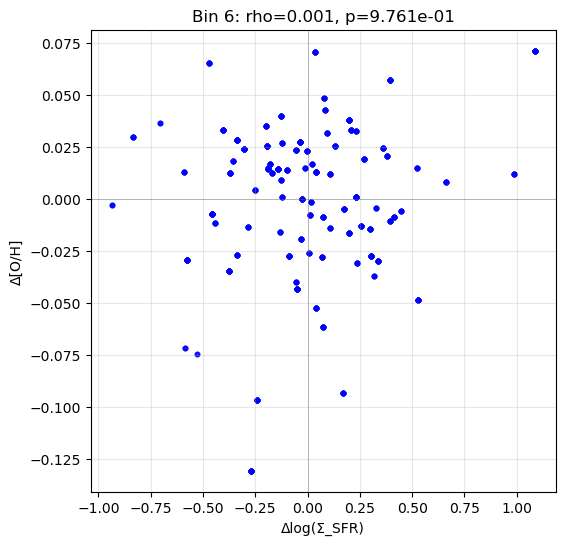

In [23]:
# Verification for the highest mass bin of NGC4330
from pathlib import Path
from astropy.io import fits
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            raise KeyError(f"No O3N2 metallicity extension found.")
    return sigM, sigSFR, oh_map

gal = 'NGC4330'
sigM, sigSFR, oh_o3n2_map = load_maps(gal)

valid_sfr = np.isfinite(sigSFR)
valid_oh = np.isfinite(oh_o3n2_map)
valid_sigM = np.isfinite(sigM)
valid_all = valid_sfr & valid_oh & valid_sigM

n_bins = 6
# Use unique values for percentile calculation
sigM_unique = np.unique(sigM[valid_all])
sigmaM_min = np.percentile(sigM_unique, 2.5)
sigmaM_max = np.percentile(sigM_unique, 97.5)
print(f"Unique sigM values: {len(sigM_unique)}")
print(f"SigmaM range (2.5-97.5%ile of unique): [{sigmaM_min:.3f}, {sigmaM_max:.3f}]")
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

# Highest mass bin (index 5)
i = 5
bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all

print(f"\nChecking Bin {i+1} (Highest Mass Bin)")
print(f"Mass range: {sigmaM_bin_edges[i]:.3f} - {sigmaM_bin_edges[i+1]:.3f}")

if np.sum(bin_mask) > 0:
    sfr_bin = sigSFR[bin_mask]
    oh_bin = oh_o3n2_map[bin_mask]
    
    sfr_offset = sfr_bin - np.mean(sfr_bin)
    oh_offset = oh_bin - np.mean(oh_bin)
    
    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    n_points = np.sum(valid_corr)
    print(f"Total valid points in bin: {n_points}")
    
    # Spearman correlation (no contour filtering)
    rho, p = spearmanr(sfr_offset[valid_corr], oh_offset[valid_corr])
    print(f"Spearman rho: {rho:.3f} (p={p:.3e})")
    
    # Data ranges
    x_data = sfr_offset[valid_corr]
    y_data = oh_offset[valid_corr]
    print(f"X range (SFR offset): {np.min(x_data):.3f} to {np.max(x_data):.3f}")
    print(f"Y range (OH offset): {np.min(y_data):.3f} to {np.max(y_data):.3f}")
    
    # Plot to visualize
    plt.figure(figsize=(6, 6))
    plt.scatter(x_data, y_data, c='blue', alpha=0.5, s=10)
    plt.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.title(f"Bin {i+1}: rho={rho:.3f}, p={p:.3e}")
    plt.xlabel('Δlog(Σ_SFR)')
    plt.ylabel('Δ[O/H]')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No data in this bin.")

Checking Bin 6 (Highest Mass Bin)
Mass range: 7.941 - 8.150
Total valid points in bin: 3163
Number of unique SFR values: 172
Number of unique OH values: 172
3-sigma bounds for SFR offset: [-1.311, 0.728]
3-sigma bounds for OH offset: [-0.173, 0.108]
Points within 3-sigma: 2379
Points removed by 3-sigma clipping: 784
Spearman rho (ALL points): 0.499 (p=9.170e-199)
Spearman rho (3-sigma clipped): -0.069 (p=7.379e-04)
X range (SFR offset): -1.236 to 0.967
Y range (OH offset): -0.189 to 0.130


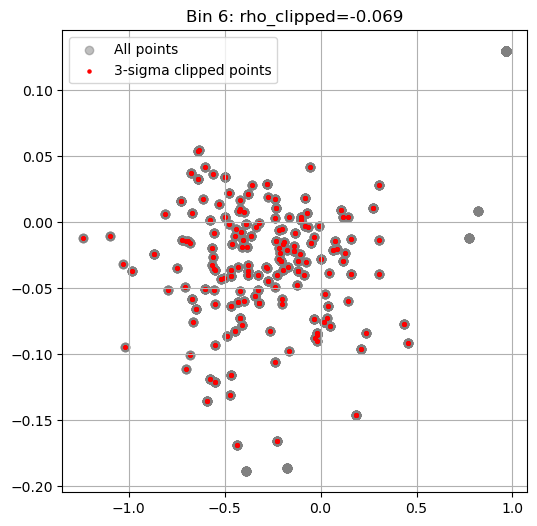

In [10]:
# Verification for the highest mass bin of NGC4330
from pathlib import Path
from astropy.io import fits
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            raise KeyError(f"No O3N2 metallicity extension found.")
    return sigM, sigSFR, oh_map

gal = 'NGC4330'
sigM, sigSFR, oh_o3n2_map = load_maps(gal)

valid_sfr = np.isfinite(sigSFR)
valid_oh = np.isfinite(oh_o3n2_map)
valid_sigM = np.isfinite(sigM)
valid_all = valid_sfr & valid_oh & valid_sigM

n_bins = 6
sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

# Highest mass bin (index 5)
i = 5
bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all

print(f"Checking Bin {i+1} (Highest Mass Bin)")
print(f"Mass range: {sigmaM_bin_edges[i]:.3f} - {sigmaM_bin_edges[i+1]:.3f}")

if np.sum(bin_mask) > 0:
    sfr_bin = sigSFR[bin_mask]
    oh_bin = oh_o3n2_map[bin_mask]
    
    sfr_offset = sfr_bin - np.mean(sfr_bin)
    oh_offset = oh_bin - np.mean(oh_bin)
    
    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    n_points = np.sum(valid_corr)
    print(f"Total valid points in bin: {n_points}")
    
    # 3-sigma clipping on unique valid data
    sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
    if n_points > 0:
        # Get unique valid data using np.unique
        sfr_data = sfr_offset[valid_corr]
        oh_data = oh_offset[valid_corr]
        
        sfr_unique = np.unique(sfr_data)
        oh_unique = np.unique(oh_data)
        
        print(f"Number of unique SFR values: {len(sfr_unique)}")
        print(f"Number of unique OH values: {len(oh_unique)}")
        
        # Calculate mean and std on unique values
        x_mean = np.mean(sfr_unique)
        x_std = np.std(sfr_unique)
        y_mean = np.mean(oh_unique)
        y_std = np.std(oh_unique)
        
        # 3-sigma bounds
        x_lower = x_mean - 3 * x_std
        x_upper = x_mean + 3 * x_std
        y_lower = y_mean - 3 * y_std
        y_upper = y_mean + 3 * y_std
        
        print(f"3-sigma bounds for SFR offset: [{x_lower:.3f}, {x_upper:.3f}]")
        print(f"3-sigma bounds for OH offset: [{y_lower:.3f}, {y_upper:.3f}]")
        
        # Apply 3-sigma clipping to all data points
        within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                        (oh_data >= y_lower) & (oh_data <= y_upper)
        sigma_clip_mask[valid_corr] = within_3sigma
    
    n_clipped = np.sum(sigma_clip_mask & valid_corr)
    n_removed = n_points - n_clipped
    print(f"Points within 3-sigma: {n_clipped}")
    print(f"Points removed by 3-sigma clipping: {n_removed}")
    
    # Spearman
    rho_all, p_all = spearmanr(sfr_offset[valid_corr], oh_offset[valid_corr])
    print(f"Spearman rho (ALL points): {rho_all:.3f} (p={p_all:.3e})")
    
    rho_clipped, p_clipped = spearmanr(sfr_offset[sigma_clip_mask & valid_corr], oh_offset[sigma_clip_mask & valid_corr])
    print(f"Spearman rho (3-sigma clipped): {rho_clipped:.3f} (p={p_clipped:.3e})")
    
    # Check for outliers
    x_data = sfr_offset[valid_corr]
    y_data = oh_offset[valid_corr]
    print(f"X range (SFR offset): {np.min(x_data):.3f} to {np.max(x_data):.3f}")
    print(f"Y range (OH offset): {np.min(y_data):.3f} to {np.max(y_data):.3f}")
    
    # Plot to visualize
    plt.figure(figsize=(6, 6))
    plt.scatter(x_data, y_data, c='gray', alpha=0.5, label='All points')
    plt.scatter(sfr_offset[sigma_clip_mask & valid_corr], oh_offset[sigma_clip_mask & valid_corr], 
                c='red', s=5, label='3-sigma clipped points')
    plt.title(f"Bin {i+1}: rho_clipped={rho_clipped:.3f}")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No data in this bin.")

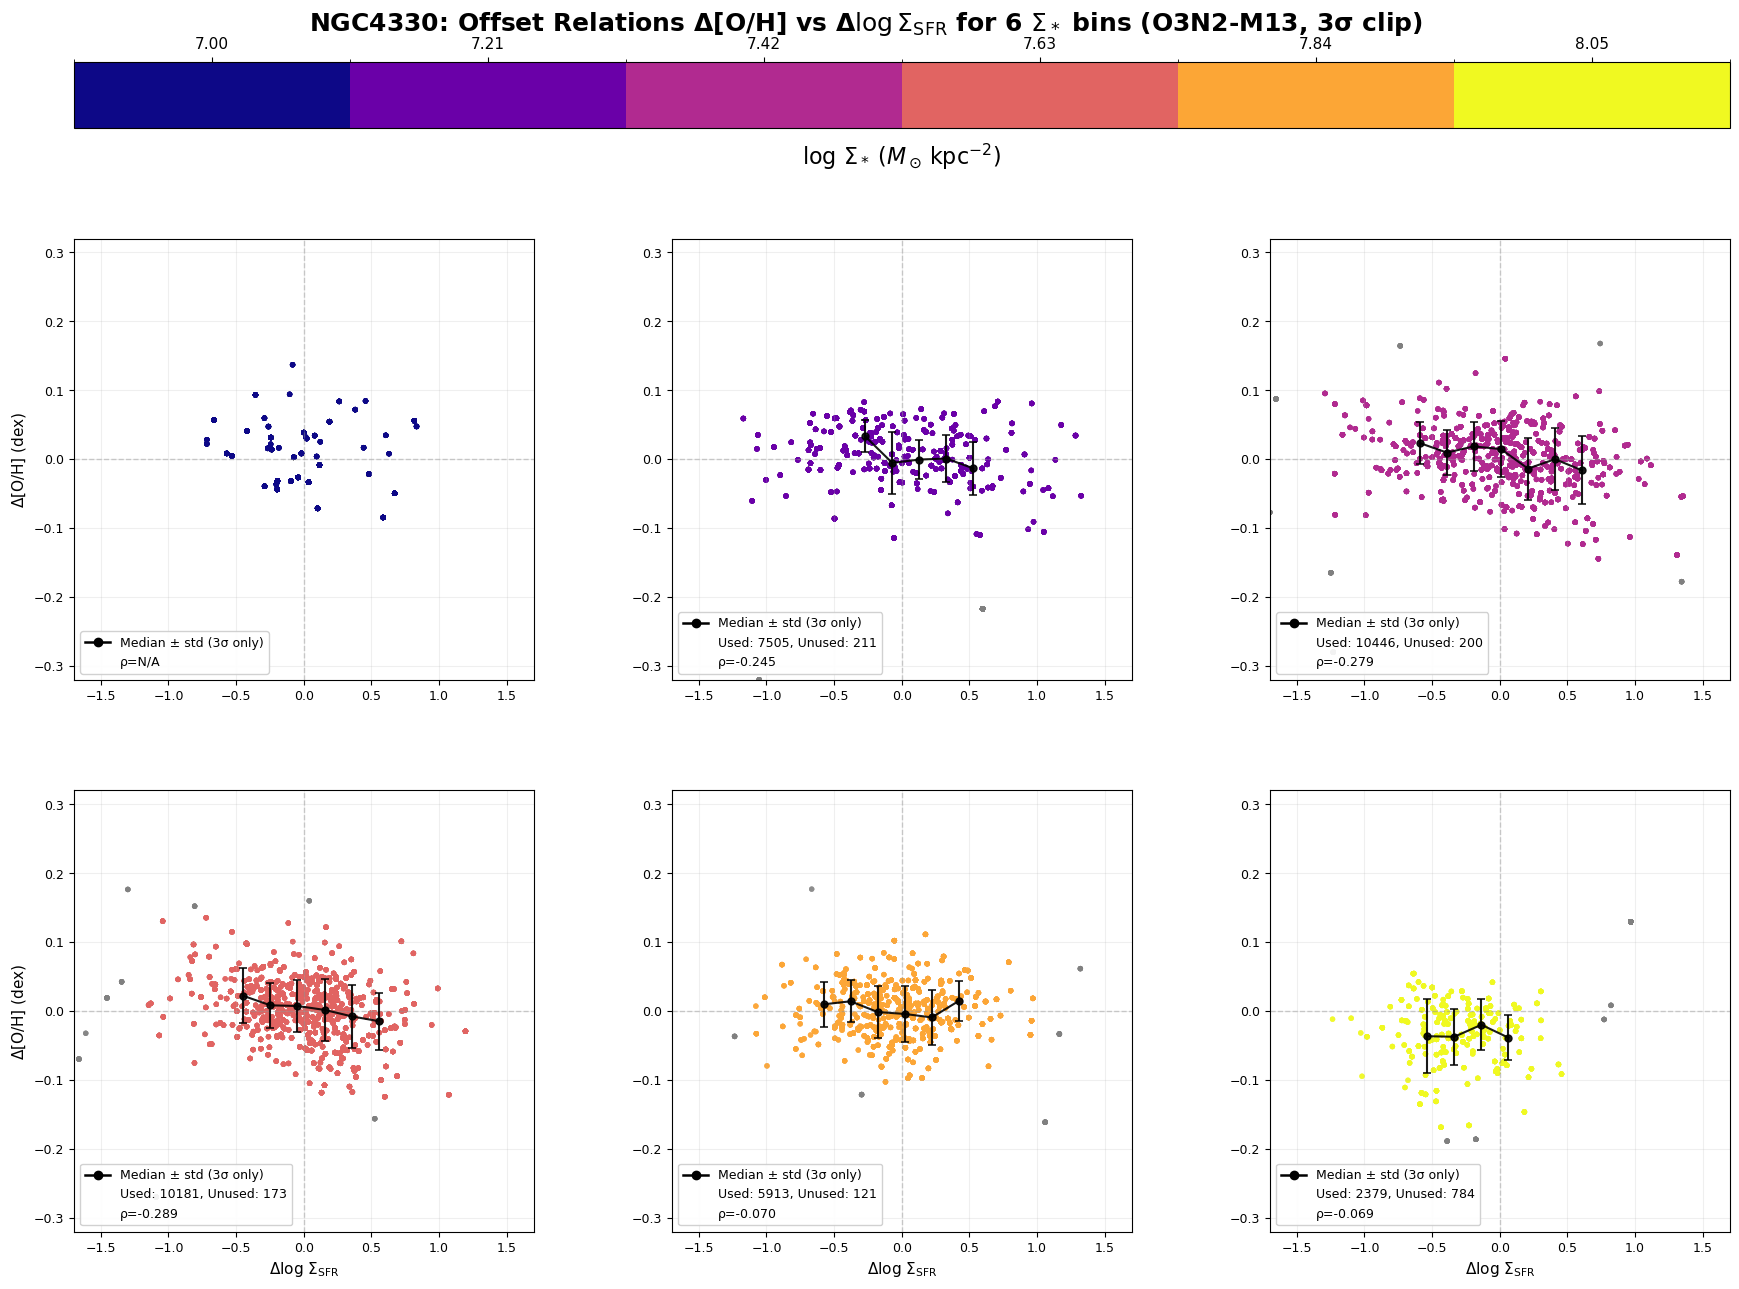


NGC4330: 6-panel offset relation grid complete!
  Number of Σ* bins: 6
  Σ* range (95%): 6.897 to 8.150
  Global Δlog(Σ_SFR) axis limits: ±1.700
  Global Δ[O/H] axis limits: ±0.320


In [13]:
# ------------------------------------------------------------------
# Plot 6 separate offset relations (one per Σ* bin) in 2x3 grid
# With shared colorbar at the top
# Updated: NGC4330, 6 bins, 95% completeness binning, Spearman rho with 3-sigma clipping
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins.

    Only keep bins where there are at least `min_unique` unique y-data
    points within the bin. Returns bin centers, medians, stds, and counts.
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        # Require sufficient unique y values in this bin
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 1.  Define 6 Σ* bins based on 95% completeness
    # ------------------------------------------------------------------
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # ------------------------------------------------------------------
    # 2.  Calculate global axis limits (same for all subplots)
    # ------------------------------------------------------------------
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)
            
            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
    
    # ------------------------------------------------------------------
    # 3.  Create 2x3 subplot grid with colorbar at top
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 13))
    
    # Create grid: 1 row for colorbar, 2 rows for subplots
    gs = gridspec.GridSpec(3, 3, figure=fig, 
                          height_ratios=[0.15, 1, 1],
                          hspace=0.35, wspace=0.3,
                          top=0.95, bottom=0.05, left=0.06, right=0.98)
    
    # Create colorbar axis at the top (spanning all columns)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Create 6 subplots in 2x3 grid
    axes = []
    for row in range(2):
        for col in range(3):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)
    
    # ------------------------------------------------------------------
    # 4.  Plot each Σ* bin in its own subplot
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]
        
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        n_pixels = np.sum(bin_mask)
        
        if n_pixels > 0:
            # Get values in this bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            # Calculate offsets WITHIN this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)
            
            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean
            
            # Validity mask in this bin
            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            
            # Get color for this bin
            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
            
            # ------------------------------------------------------------------
            # Calculate 3-sigma clipping mask on unique valid data
            # ------------------------------------------------------------------
            sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 0:
                # Get unique valid data using np.unique
                sfr_data = sfr_offset[valid_corr]
                oh_data = oh_offset[valid_corr]
                
                sfr_unique = np.unique(sfr_data)
                oh_unique = np.unique(oh_data)
                
                # Calculate mean and std on unique values
                x_mean = np.mean(sfr_unique)
                x_std = np.std(sfr_unique)
                y_mean = np.mean(oh_unique)
                y_std = np.std(oh_unique)
                
                # 3-sigma bounds
                x_lower = x_mean - 3 * x_std
                x_upper = x_mean + 3 * x_std
                y_lower = y_mean - 3 * y_std
                y_upper = y_mean + 3 * y_std
                
                # Apply 3-sigma clipping to all data points
                within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                                (oh_data >= y_lower) & (oh_data <= y_upper)
                sigma_clip_mask[valid_corr] = within_3sigma
            
            # Count used and unused data
            n_used = np.sum(sigma_clip_mask & valid_corr)
            n_unused = np.sum(valid_corr) - n_used
            
            # Plot unused data in gray first (so it's in background)
            if n_unused > 0:
                unused_mask = valid_corr & ~sigma_clip_mask
                ax.scatter(sfr_offset[unused_mask], oh_offset[unused_mask], 
                          c='gray', s=15, alpha=0.3, edgecolors='none', rasterized=True)
            
            # Plot used data in bin color on top
            if n_used > 0:
                ax.scatter(sfr_offset[sigma_clip_mask & valid_corr], 
                          oh_offset[sigma_clip_mask & valid_corr], 
                          c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)
            
            # ------------------------------------------------------------------
            # Calculate median trend using only points within 3-sigma
            # and requiring at least `min_unique` unique y-values per bin
            # ------------------------------------------------------------------
            x_trend = sfr_offset[sigma_clip_mask]
            y_trend = oh_offset[sigma_clip_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size > 0
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)
            
            # ------------------------------------------------------------------
            # Spearman rho: only for points within 3-sigma and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
                spearman_rho, spearman_p = spearmanr(sfr_offset[sigma_clip_mask & valid_corr],
                                                oh_offset[sigma_clip_mask & valid_corr])
                r_label = f'ρ={spearman_rho:.3f}'
            else:
                spearman_rho, spearman_p = np.nan, np.nan
                r_label = 'ρ=N/A'
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            
            # Set symmetric limits (global)
            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            
            # Grid
            ax.grid(True, alpha=0.2)
            
            # Legend entries for each subplot: median, 3-sigma, n and r
            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (3σ only)')
            ]
            # Only show counts if Spearman is available
            if r_label != 'ρ=N/A':
                legend_elements.append(Line2D([0], [0], color='none',
                       label=f'Used: {n_used}, Unused: {n_unused}'))
            legend_elements.append(Line2D([0], [0], color='none',
                       label=f'{r_label}'))
            
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)
            
            # Labels (only on left and bottom edges)
            if i % 3 == 0:  # Left column
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            if i >= 3:  # Bottom row
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)
            
            ax.tick_params(labelsize=9)
        else:
            # No data in this bin
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # ------------------------------------------------------------------
    # 5.  Create horizontal colorbar at the top
    # ------------------------------------------------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')
    
    fig.suptitle(rf'{gal}: Offset Relations Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ for {n_bins} $\Sigma_*$ bins ({indicator_name}, 3σ clip)',
                fontsize=18, y=0.99, fontweight='bold')
    
    plt.show()
    
    print(f"\n{gal}: {n_bins}-panel offset relation grid complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")
